# Attempting to analyze cases

For now, eliminate pretor window and just go up until first tornado report.

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [78]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")

# Functions

In [3]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list, lower_limit, upper_limit, legend_position, figsizex, figsizey):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(figsizex, figsizey))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-upper_limit, lower_limit)  # Only negative x values
    ax.set_ylim(-lower_limit, upper_limit)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold')

    for u,v in zip(u_list, v_list):
        
        #for i,z in zip([0, 0.5, 1, 2], enumerate([0,45,95,195])):
        for i,z in zip([0, 0.5, 1, 2], [0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.5,color='k',zorder=30)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
            except: pass
    
    ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc=legend_position, fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

Why not just make a nf ff column instead of pretor_nf, pretor_ff, etc... I think I'm dumb for only just thinking of that...

In [4]:
import pandas as pd
import numpy as np

#def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, tor_time):

def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, angle2, tor_time):
    '''
    angle2 = angle above 0 degrees that you want to be greater than (upper right quadrant)
    '''
    df_tor = pd.DataFrame()
    df_nontor = pd.DataFrame()
    df_all_tor = pd.DataFrame()
    df_all_nontor = pd.DataFrame()
    
    try:
        print(csv_name)
        df = pd.read_csv(csv_name)
        print(f'CSV size: {np.shape(df)}')

        # Filter data based on distance and angle
        nf = df[(df['Distance'] <= nf_dist) & ((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]
        ff = df[(df['Distance'] > ff_dist) & ((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]

        inflow = df[((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]
        # Check if the dataset contains tornadic cases
        if df['Time From Tor (min)'].ne('nontor').any():
            # nf AND ff
            tor = inflow
            pretor = inflow[inflow['Time From Tor (min)'] < tor_time]
            dtor = inflow[inflow['Time From Tor (min)'] == tor_time]
            posttor = inflow[inflow['Time From Tor (min)'] > tor_time]

            #nf
            tor_nf = nf
            pretor_nf = nf[nf['Time From Tor (min)'] < tor_time]
            dtor_nf = nf[nf['Time From Tor (min)'] == tor_time]
            posttor_nf = nf[nf['Time From Tor (min)'] > tor_time]

            # ff
            tor_ff = ff
            pretor_ff = ff[ff['Time From Tor (min)'] < tor_time]
            dtor_ff = ff[ff['Time From Tor (min)'] == tor_time]
            posttor_ff = ff[ff['Time From Tor (min)'] > tor_time]

            tor_inflow = [tor, pretor, dtor, posttor]
            inflow_labels = ['tor', 'pretor', 'dtor', 'posttor']
            tor_seg = [tor_nf, pretor_nf, dtor_nf, posttor_nf, tor_ff, pretor_ff, dtor_ff, posttor_ff]
            labels = ['tor nf','pretor nf', 'dtor nf', 'posttor nf', 'tor ff', 'pretor ff', 'dtor ff', 'posttor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for infl, torall in zip(tor_inflow, inflow_labels):
                    seg = infl[infl['u or v'] == wind]
                    seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                    
                    df_temp = pd.DataFrame(seg_avg).T
                    df_temp['label'] = torall
                    df_temp['wind'] = wind
                    df_temp['date'] = dates

                    df_tor = pd.concat([df_tor, df_temp], ignore_index=True)
                    
                    for tor, lab in zip(tor_seg, labels):
                        seg = tor[tor['u or v'] == wind]
                        seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                        
                        df_temp = pd.DataFrame(seg_avg).T
                        df_temp['label'] = lab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
                        
                        df_all_tor = pd.concat([df_all_tor, df_temp], ignore_index=True)

        # Check if the dataset contains nontornadic cases
        if df['Time From Tor (min)'].eq('nontor').any():

            nontor = inflow
            nf_nt = df[(df['Distance'] <= nf_dist) & (df['Angle'] <= angle1)]
            ff_nt = df[(df['Distance'] > ff_dist) & (df['Angle'] <= angle1)]

            nontor_inflow = [nontor]
            nt_lab = ['nontor']
            nontor_seg = [nf_nt, ff_nt]
            nontor_labels = ['nontor nf', 'nontor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for nt, ntlabel in zip(nontor_inflow, nt_lab):
                    ntseg = nt[nt['u or v'] == wind]
                    ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)

                    df_temp = pd.DataFrame(ntseg_avg).T
                    df_temp['label'] = nt_lab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_nontor = pd.concat([df_nontor, df_temp], ignore_index=True)
                    
                    for nontor, nonlab in zip(nontor_seg, nontor_labels):
                        ntseg = nontor[nontor['u or v'] == wind]
                        ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
    
                        df_temp = pd.DataFrame(ntseg_avg).T
                        df_temp['label'] = nonlab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
    
                        df_all_nontor = pd.concat([df_all_nontor, df_temp], ignore_index=True)

    except FileNotFoundError:
        print(f"File not found: {csv_name}")
        pass

    return df_tor, df_nontor, df_all_tor, df_all_nontor

In [5]:
def averaging_u_and_v(comp_tor_all, comp_nontor_all):

    # tor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)
    # tor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)

    # tor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    # tor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    
    pretor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    pretor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    
    dtor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    dtor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    
    posttor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    posttor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    
    pretor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    pretor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    
    dtor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    dtor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    
    posttor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)
    posttor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)

    nontor_u_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    nontor_v_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    
    nontor_u_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)
    nontor_v_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)

    tor_u_nf = np.nanmean([pretor_u_nf, dtor_u_nf, posttor_u_nf], axis=0)
    tor_v_nf = np.nanmean([pretor_v_nf, dtor_v_nf, posttor_v_nf], axis=0)

    tor_u_ff = np.nanmean([pretor_u_ff, dtor_u_ff, posttor_u_ff], axis=0)
    tor_v_ff = np.nanmean([pretor_v_ff, dtor_v_ff, posttor_v_ff], axis=0)
                          
    
    return locals()

# Dates

In [6]:
#dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230611', '20230612', '20240502', '20240504', '20240519', '20240523', '20240602']

# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240502', '20240504', '20240506',
#           '20240523', '20240528']
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240528', '20240602']
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

# VADs scan data (heights, ranges, etc)

In [ ]:
r = pyart.io.read('/Volumes/Buhrman_4TB/dealiased_data/LIFT24/20240519/ka1/Ka1240519220312.nc')

In [ ]:
np.shape(r.range['data'])

# Not composited u and v

In [7]:
df_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        try:
            date = pd.DataFrame()
            not_comp_file_name = f'case_dfs/new/{d}_uv_{ka}_all.csv'
            print(not_comp_file_name)
            df = pd.read_csv(not_comp_file_name)
            print(np.shape(df))
            df['Date'] = d
            
            if df['Time From Tor (min)'].eq('nontor').any():
                df['Tor or Nontor'] = 'nontor'
            else:
                df['Tor or Nontor'] = 'tor'
            
            df_all = pd.concat([df_all, df], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name}")
            continue

case_dfs/new/20220523_uv_ka1_all.csv
(192, 201)
case_dfs/new/20220524_uv_ka1_all.csv
(134, 201)
case_dfs/new/20220611_uv_ka1_all.csv
(180, 201)
case_dfs/new/20230524_uv_ka1_all.csv
File not found: case_dfs/new/20230524_uv_ka1_all.csv
case_dfs/new/20230527_uv_ka1_all.csv
(572, 201)
case_dfs/new/20230601_uv_ka1_all.csv
File not found: case_dfs/new/20230601_uv_ka1_all.csv
case_dfs/new/20230609_uv_ka1_all.csv
(392, 201)
case_dfs/new/20230611_uv_ka1_all.csv
(572, 201)
case_dfs/new/20230612_uv_ka1_all.csv
File not found: case_dfs/new/20230612_uv_ka1_all.csv
case_dfs/new/20230613_uv_ka1_all.csv
(206, 201)
case_dfs/new/20230615_uv_ka1_all.csv
(1974, 201)
case_dfs/new/20240427_uv_ka1_all.csv
(388, 201)
case_dfs/new/20240501_uv_ka1_all.csv
(1134, 201)
case_dfs/new/20240502_uv_ka1_all.csv
(834, 201)
case_dfs/new/20240504_uv_ka1_all.csv
(1134, 201)
case_dfs/new/20240506_uv_ka1_all.csv
File not found: case_dfs/new/20240506_uv_ka1_all.csv
case_dfs/new/2024051920240523_uv_ka1_all.csv
File not found: 

In [8]:
df_all_new = pd.DataFrame()
for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            try:
                not_comp_file_name_new = file
                print(not_comp_file_name_new)
                df_new = pd.read_csv(not_comp_file_name_new)
                df_new['Date'] = d
                print(np.shape(df_new))
                if df_new['Time From Tor (min)'].eq('nontor').any():
                    df_new['Tor or Nontor'] = 'nontor'
                else:
                    df_new['Tor or Nontor'] = 'tor'
                    
                df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
            except FileNotFoundError:
                print(f"File not found: {not_comp_file_name_new}")
                continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/tornadic/20240502_uv_ka1_all.csv
(784, 202)
case_dfs/new/new_secondtrip/nontornadic/20240504_uv_ka1_all.csv
(780, 202)
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
(1050, 202)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
(262, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/2023052

In [9]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,193,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime,Date,Tor or Nontor
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,-10.014693,-9.976872,-9.931767,u,24.796636,282.132826,-54.833333,2022-05-23 22:55:10,20220523,tor
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,-9.040518,-8.965948,-8.903369,u,25.813325,282.602215,-54.333333,2022-05-23 22:55:40,20220523,tor
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,-8.912380,-8.836675,-8.764936,u,26.810463,283.027394,-53.833333,2022-05-23 22:56:10,20220523,tor
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,-8.237093,-8.155903,-8.073130,u,27.817252,283.424013,-53.35,2022-05-23 22:56:39,20220523,tor
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,-7.348469,-7.272206,-7.229976,u,28.820999,283.791452,-52.85,2022-05-23 22:57:09,20220523,tor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,-1.635275,-1.568471,-1.420855,-1.320286,-1.320286,-1.102728,-1.051306,-0.936231,-0.836507,-0.828301,...,3.857773,3.858832,3.863916,v,17.730159,10.589711,63.566667,2023-06-16 00:34:34,20230615,tor
6596,-3.691865,-3.578943,-3.513133,-3.421503,-3.421503,-3.236247,-3.157359,-3.030900,-2.966462,-2.847811,...,2.436110,2.436770,2.438994,v,17.730159,5.589711,63.783333,2023-06-16 00:34:47,20230615,tor
6597,-3.230326,-3.062784,-2.947798,-2.882831,-2.882831,-2.730972,-2.657030,-2.451415,-2.396161,-2.222835,...,2.567304,2.570550,2.575942,v,17.730159,5.589711,64.0,2023-06-16 00:35:00,20230615,tor
6598,-4.028626,-3.970635,-3.912552,-3.842394,-3.842394,-3.703241,-3.636965,-3.529508,-3.464480,-3.379116,...,2.450934,2.459235,2.459529,v,17.730194,5.590613,66.033333,2023-06-16 00:37:02,20230615,tor


# Sorting noncomp u and v

In [325]:
dist = 20
angle = 90
angle_upper = 315
nf_u_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
nf_v_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

ff_u_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper))  & (df_all['u or v'] == 'u')]
ff_v_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [326]:
inflow_u_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
inflow_v_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [327]:
nf_u_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
nf_v_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

ff_u_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
ff_v_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [328]:
inflow_u_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
inflow_v_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [329]:
def categorize_data(df):
    tor_time = 0
    
    # Convert 'Time From Tor (min)' to numeric, setting errors='coerce' to turn 'nontor' into NaN
    df = df.copy()  # Prevent modifying original DataFrame
    df['Time Numeric'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
    
    categories = {
        "nontor": df[df['Time From Tor (min)'] == 'nontor'],
        "tor": df[df['Time From Tor (min)'] != 'nontor'],
        "pretor": df[df['Time Numeric'].notna() & (df['Time Numeric'] < tor_time)],
        "dtor": df[df['Time Numeric'].notna() & (df['Time Numeric'] == tor_time)],
        "posttor": df[df['Time Numeric'].notna() & (df['Time Numeric'] > tor_time)]
    }
    
    return categories

# Apply function to each dataset
nf_u_categories = categorize_data(nf_u_all)
ff_u_categories = categorize_data(ff_u_all)
nf_v_categories = categorize_data(nf_v_all)
ff_v_categories = categorize_data(ff_v_all)


nf_u_categories_new = categorize_data(nf_u_all_new)
ff_u_categories_new = categorize_data(ff_u_all_new)
nf_v_categories_new = categorize_data(nf_v_all_new)
ff_v_categories_new = categorize_data(ff_v_all_new)

inflow_u_categories = categorize_data(inflow_u_all)
inflow_v_categories = categorize_data(inflow_v_all)

inflow_u_categories_new = categorize_data(inflow_u_all_new)
inflow_v_categories_new = categorize_data(inflow_v_all_new)
# Example usage
#nf_u_categories['pretor']  # Near-field U pre-tornadic

In [330]:
nf_u_categories['tor'].Date

73       20220523
74       20220523
75       20220523
76       20220523
77       20220523
           ...   
10701    20230615
10702    20230615
10703    20230615
10704    20230615
10705    20230615
Name: Date, Length: 228, dtype: object

In [ ]:
np.shape(nf_u_categories['nontor'])

In [ ]:
np.shape(ff_u_categories['nontor'])

In [ ]:
np.shape(nf_u_categories['tor'])

In [ ]:
np.shape(ff_u_categories['tor'])

In [ ]:
np.shape(nf_u_categories_new['nontor'])

In [ ]:
np.shape(ff_u_categories_new['nontor'])

In [ ]:
np.shape(nf_u_categories_new['tor'])

In [ ]:
inflow_u_categories_new

In [ ]:
np.shape(ff_u_categories_new['tor'])

# Bulk shear vector percent perpendicular to storm motion (% streamwise voricity )

Is this already accounted for in SRH?

In [ ]:
def bulk_shear(u0, v0, u1, v1):
    '''
    u0 = bottom level
    u1 = top level
    This function gives a vector pointing from the low level to the upper level
    '''
    delta_u = u1 - u0
    delta_v = v1 - v0

In [ ]:
for d in sorted(set(df_all_new['Date'].values())):
    
    bulk_shear

In [ ]:
def percent_streamwise_vorticity(u, v, heights):
    """
    Compute the percent of streamwise vorticity at each level.

    Parameters:
    - u: Array of storm-relative u-wind components
    - v: Array of storm-relative v-wind components
    - heights: Array of heights corresponding to u, v

    Returns:
    - percent_sw: Array of percent streamwise vorticity at each level
    """
    du_dz = np.gradient(u, heights, axis=0)
    dv_dz = -np.gradient(v, heights, axis=0)
    V_mag = np.sqrt(u**2 + v**2)  # Wind magnitude
    omega_s = (du_dz * (u / V_mag)) + (dv_dz * (v / V_mag))  # Streamwise vorticity
    omega_h = np.sqrt(np.array(du_dz)**2 + np.array(dv_dz)**2)  # Total horizontal vorticity magnitude

    percent_sw = (omega_s / omega_h) * 100  # Convert to percent
    
    return percent_sw

In [331]:
def compute_critical_angle(u_surf, v_surf, u_ref, v_ref, u_storm, v_storm):
    """
    Compute the critical angle between the storm motion and low-level shear vector.

    Parameters:
        u_surf, v_surf: Wind components at the surface
        u_ref, v_ref: Wind components at the reference level (e.g., 500m or 1km)
        u_storm, v_storm: Storm motion components

    Returns:
        Critical angle in degrees
    """
    # Compute shear vector (reference level minus surface)
    shear_u = u_ref - u_surf
    shear_v = v_ref - v_surf

    # Compute magnitudes
    shear_mag = np.sqrt(shear_u**2 + shear_v**2)
    storm_mag = np.sqrt(u_storm**2 + v_storm**2)

    # Compute dot product between shear vector and storm motion
    dot_product = (u_storm * shear_u) + (v_storm * shear_v)

    # Compute critical angle
    critical_angle_rad = np.arccos(dot_product / (storm_mag * shear_mag))
    critical_angle_deg = np.degrees(critical_angle_rad)

    return critical_angle_deg

tor
avg tor critical angle: 63.29794897550633


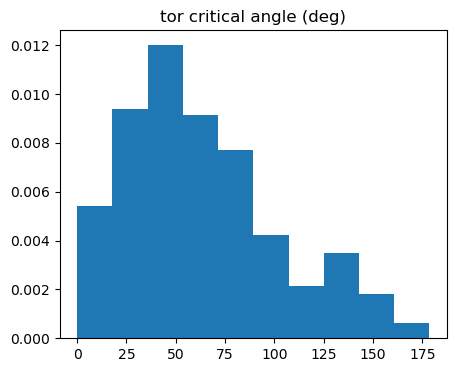

nontor
avg nontor critical angle: 65.21911087594003


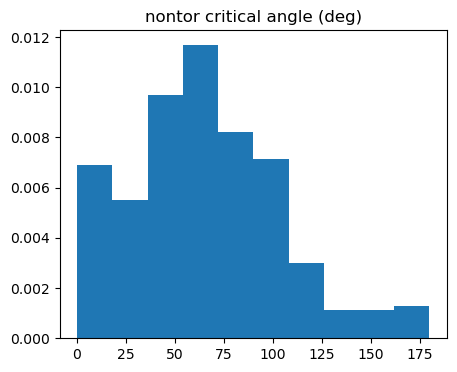

In [332]:
us = [inflow_u_categories_new, inflow_u_categories_new]
vs = [inflow_v_categories_new, inflow_v_categories_new]
cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']

critical_angle_df = pd.DataFrame()

for ucomp, vcomp, col in zip(us, vs, cats):
    u0 = np.array(ucomp[col].iloc[:, 0])
    v0 = np.array(vcomp[col].iloc[:, 0])

    u500 = np.array(ucomp[col].iloc[:, 50])
    v500 = np.array(vcomp[col].iloc[:, 50])

    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()

    print(col)

    ca['tor or nontor'] = [col] * len(critical_angle_deg)
    ca['critical_angle'] = critical_angle_deg

    critical_angle_df = pd.concat([critical_angle_df, ca])
    
    print(f'avg {col} critical angle: {np.nanmean(critical_angle_deg)}')
    
    fig = plt.figure(figsize=(5,4))
    counts, bins = np.histogram(critical_angle_deg, density=True)
    plt.hist(bins[:-1], bins, weights=counts)
    #plt.boxplot([avg_omega_s_percent_2km])
    plt.title(f'{col} critical angle (deg)')
    plt.show()

In [335]:
df = critical_angle_df
x = np.nanmean(df[df['tor or nontor'] == 'tor']['critical_angle'])
y = np.nanmean(df[df['tor or nontor'] == 'nontor']['critical_angle'])

In [338]:
data = df[df['tor or nontor'] == 'tor']['critical_angle']
confidence_level = 0.95
degrees_freedom = len(data) - 1
x_strd_error = stats.sem(data, nan_policy='omit')

x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)

In [339]:
data = df[df['tor or nontor'] == 'nontor']['critical_angle']
confidence_level = 0.95
degrees_freedom = len(data) - 1
y_strd_error = stats.sem(data, nan_policy='omit')

y_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=y, scale=y_strd_error)

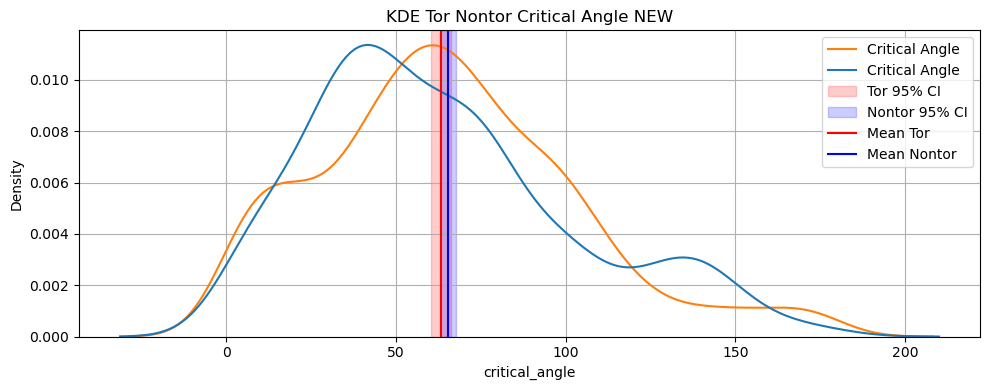

In [344]:
#plt.figure(figsize = (12, 4))
df = critical_angle_df
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='critical_angle', hue='tor or nontor', common_norm=False, label = 'Critical Angle')
                
plt.title('KDE Tor Nontor Critical Angle NEW')


plt.axvspan(x_95conf[0], x_95conf[1], color='red', alpha=0.2, label='Tor 95% CI')
plt.axvspan(y_95conf[0], y_95conf[1], color='blue', alpha=0.2, label='Nontor 95% CI')
plt.axvline(x, color='red', label='Mean Tor')
plt.axvline(x=y, color='blue', label='Mean Nontor')
plt.grid()
plt.tight_layout()
#plt.legend(['Tor', 'Nontor',f'Tor Mean: {x}', f'Nontor Mean: {y}'])
plt.legend()
plt.show()

# Noncomposited avg hodographs

In [ ]:
tor_u_nf = np.nanmean(nf_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_nf = np.nanmean(nf_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff = np.nanmean(ff_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_ff = np.nanmean(ff_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_nf_new = np.nanmean(nf_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_nf_new = np.nanmean(nf_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_nf_new = np.nanmean(nf_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_nf_new = np.nanmean(nf_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_nf_new = np.nanmean(nf_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_nf_new = np.nanmean(nf_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_nf_new = np.nanmean(nf_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_nf_new = np.nanmean(nf_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_nf_new = np.nanmean(nf_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_nf_new = np.nanmean(nf_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff_new = np.nanmean(ff_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_ff_new = np.nanmean(ff_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_ff_new = np.nanmean(ff_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_ff_new = np.nanmean(ff_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_ff_new = np.nanmean(ff_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_ff_new = np.nanmean(ff_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_ff_new = np.nanmean(ff_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_ff_new = np.nanmean(ff_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_ff_new = np.nanmean(ff_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_ff_new = np.nanmean(ff_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
hodo_plot([tor_u_nf, pretor_u_nf, dtor_u_nf, posttor_u_nf, nontor_u_nf], [tor_u_ff, pretor_v_nf, dtor_v_nf, posttor_v_nf, 
                                                                             nontor_v_nf], heights, 25, 
    'Near-Field Composites (No Comp Prior)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([tor_u_ff, pretor_u_ff, dtor_u_ff, posttor_u_ff, nontor_u_ff], [tor_v_ff, pretor_v_ff, dtor_v_ff, posttor_v_ff, 
                                                                             nontor_v_ff], heights, 25, 
    'Far-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_nf_new, dtor_u_nf_new, posttor_u_nf_new, nontor_u_nf_new], [pretor_v_nf_new, dtor_v_nf_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Near-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_ff_new, dtor_u_ff_new, posttor_u_ff_new, nontor_u_ff_new], [pretor_v_ff_new, dtor_v_ff_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Far-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'During Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 8,8)

# Compositing cases

In [17]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 90
angle2 = 315
tor_time = 0

In [18]:
comp_tor_all_nodist = pd.DataFrame()
comp_nontor_all_nodist = pd.DataFrame()

comp_tor_all = pd.DataFrame()
comp_nontor_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        comp_tor_nodist, comp_nontor_nodist, comp_tor, comp_nontor = comp_per_case(f'case_dfs/new/{d}_uv_{ka}_all.csv', ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
        #comp_tor['Tor or Nontor'] = 'tor'
        #comp_nontor['Tor or Nontor'] = 'nontor'

        comp_tor_all_nodist = pd.concat([comp_tor_all_nodist, comp_tor_nodist])
        comp_nontor_all_nodist = pd.concat([comp_nontor_all_nodist, comp_nontor_nodist])
        
        comp_tor_all = pd.concat([comp_tor_all, comp_tor])
        comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

case_dfs/new/20220523_uv_ka1_all.csv
CSV size: (192, 201)
case_dfs/new/20220524_uv_ka1_all.csv
CSV size: (134, 201)
case_dfs/new/20220611_uv_ka1_all.csv
CSV size: (180, 201)
case_dfs/new/20230524_uv_ka1_all.csv
File not found: case_dfs/new/20230524_uv_ka1_all.csv
case_dfs/new/20230527_uv_ka1_all.csv
CSV size: (572, 201)
case_dfs/new/20230601_uv_ka1_all.csv
File not found: case_dfs/new/20230601_uv_ka1_all.csv
case_dfs/new/20230609_uv_ka1_all.csv
CSV size: (392, 201)
case_dfs/new/20230611_uv_ka1_all.csv
CSV size: (572, 201)
case_dfs/new/20230612_uv_ka1_all.csv
File not found: case_dfs/new/20230612_uv_ka1_all.csv
case_dfs/new/20230613_uv_ka1_all.csv
CSV size: (206, 201)
case_dfs/new/20230615_uv_ka1_all.csv
CSV size: (1974, 201)


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], 

case_dfs/new/20240427_uv_ka1_all.csv
CSV size: (388, 201)
case_dfs/new/20240501_uv_ka1_all.csv
CSV size: (1134, 201)
case_dfs/new/20240502_uv_ka1_all.csv
CSV size: (834, 201)
case_dfs/new/20240504_uv_ka1_all.csv
CSV size: (1134, 201)
case_dfs/new/20240506_uv_ka1_all.csv
File not found: case_dfs/new/20240506_uv_ka1_all.csv
case_dfs/new/2024051920240523_uv_ka1_all.csv
File not found: case_dfs/new/2024051920240523_uv_ka1_all.csv
case_dfs/new/20240528_uv_ka1_all.csv
CSV size: (1082, 201)
case_dfs/new/20240602_uv_ka1_all.csv
CSV size: (274, 201)
case_dfs/new/20220523_uv_ka2_all.csv
CSV size: (106, 201)
case_dfs/new/20220524_uv_ka2_all.csv
File not found: case_dfs/new/20220524_uv_ka2_all.csv
case_dfs/new/20220611_uv_ka2_all.csv
File not found: case_dfs/new/20220611_uv_ka2_all.csv
case_dfs/new/20230524_uv_ka2_all.csv
CSV size: (352, 201)
case_dfs/new/20230527_uv_ka2_all.csv
File not found: case_dfs/new/20230527_uv_ka2_all.csv
case_dfs/new/20230601_uv_ka2_all.csv
File not found: case_dfs/new/2

/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:54: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], 

In [19]:
comp_tor_all_nodist_new = pd.DataFrame()
comp_nontor_all_nodist_new = pd.DataFrame()

comp_tor_all_new = pd.DataFrame()
comp_nontor_all_new = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new = pd.concat([comp_nontor_all_new, comp_nontor_new])

/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)


case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
CSV size: (120, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
CSV size: (100, 201)
0
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
CSV size: (506, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
CSV size: (388, 201)
0
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
CSV size: (20, 201)
0
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
CSV size: (572, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
CSV size: (314, 201)


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], 

0
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
CSV size: (850, 201)
0
case_dfs/new/new_secondtrip/tornadic/20240502_uv_ka1_all.csv
CSV size: (784, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20240504_uv_ka1_all.csv
CSV size: (780, 201)
0
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
CSV size: (1050, 201)
0
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
CSV size: (262, 201)


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:101: RuntimeWarning: Mean of empty slice
  ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:101: RuntimeWarning: Mean of empty slice
  ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[

199
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
CSV size: (20, 201)
199
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
CSV size: (284, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
CSV size: (198, 201)
0
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka2_all.csv
CSV size: (352, 201)
199


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:54: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/688578394.py:65: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], 

In [20]:
comp_tor_all_nodist.dropna(inplace=True)
comp_tor_all_nodist_new.dropna(inplace=True)

comp_nontor_all_nodist.dropna(inplace=True)
comp_nontor_all_nodist_new.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [21]:
comp_tor_all.dropna(inplace=True)
comp_nontor_all.dropna(inplace=True)
comp_tor_all_new.dropna(inplace=True)
comp_nontor_all_new.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [ ]:
comp_nontor_all.date.value_counts()

In [ ]:
comp_tor_all_new.date.value_counts()

In [ ]:
comp_tor_all_new.date.value_counts()

In [ ]:
comp_tor_all_new.label.value_counts()

# Composite Hodographs

In [ ]:
old_2ndtrip = averaging_u_and_v(comp_tor_all, comp_nontor_all)
new_2ndtrip = averaging_u_and_v(comp_tor_all_new, comp_nontor_all_new)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['pretor_u_nf'], old_2ndtrip['dtor_u_nf'], old_2ndtrip['posttor_u_nf'], 
           old_2ndtrip['nontor_u_nf']], 
           [old_2ndtrip['tor_v_nf'], old_2ndtrip['pretor_v_nf'], old_2ndtrip['dtor_v_nf'], old_2ndtrip['posttor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6, 6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['nontor_u_nf']], [old_2ndtrip['tor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'All Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['pretor_u_ff'], old_2ndtrip['dtor_u_ff'], old_2ndtrip['posttor_u_ff'], old_2ndtrip['nontor_u_ff']], 
           [old_2ndtrip['pretor_v_ff'], old_2ndtrip['dtor_v_ff'], old_2ndtrip['posttor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_ff'], old_2ndtrip['nontor_u_ff']], [old_2ndtrip['tor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'Nontornadic'], 5, 25, 'lower left', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['pretor_u_nf'], new_2ndtrip['dtor_u_nf'], new_2ndtrip['posttor_u_nf'], new_2ndtrip['nontor_u_nf']], 
           [new_2ndtrip['tor_v_nf'], new_2ndtrip['pretor_v_nf'], new_2ndtrip['dtor_v_nf'], new_2ndtrip['posttor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['pretor_u_ff'], new_2ndtrip['dtor_u_ff'], new_2ndtrip['posttor_u_ff'], new_2ndtrip['nontor_u_ff']], 
           [new_2ndtrip['tor_v_ff'], new_2ndtrip['pretor_v_ff'],new_2ndtrip['dtor_v_ff'], new_2ndtrip['posttor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic','Pre Tornadic', 'Tor', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right',6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf'], new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf'], new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor Composites NEW', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Tor VS Nontor NF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic NF', 'Nontornadic NF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor FF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

In [ ]:
784/196

In [ ]:
tor_winds_new

In [ ]:
tor_nf_u = tor_winds_new['NF_u_mean_0-2km']
tor_nf_v = tor_winds_new['NF_v_mean_0-2km']
tor_ff_u = tor_winds_new['FF_u_mean_0-2km']
tor_ff_v = tor_winds_new['FF_v_mean_0-2km']

avg_tor_nf_u = np.nansum([tor_nf_u.iloc[:196], tor_nf_u.iloc[196:392], tor_nf_u.iloc[392:588], tor_nf_u.iloc[588:]], axis=0) / 4
avg_tor_nf_v = np.nansum([tor_nf_v.iloc[:196], tor_nf_v.iloc[196:392], tor_nf_v.iloc[392:588], tor_nf_v.iloc[588:]], axis=0) / 4

avg_tor_ff_u = np.nansum([tor_ff_u.iloc[:196], tor_ff_u.iloc[196:392], tor_ff_u.iloc[392:588], tor_ff_u.iloc[588:]], axis=0) / 4
avg_tor_ff_v = np.nansum([tor_ff_v.iloc[:196], tor_ff_v.iloc[196:392], tor_ff_v.iloc[392:588], tor_ff_v.iloc[588:]], axis=0) / 4

In [ ]:
nontor_nf_u = nontor_winds_new['NF_u_mean_0-2km']
nontor_nf_v = nontor_winds_new['NF_v_mean_0-2km']
nontor_ff_u = nontor_winds_new['FF_u_mean_0-2km']
nontor_ff_v = nontor_winds_new['FF_v_mean_0-2km']

avg_nontor_nf_u = np.nansum([nontor_nf_u.iloc[:196], nontor_nf_u.iloc[196:392]], axis=0)/ 2
avg_nontor_nf_v = np.nansum([nontor_nf_v.iloc[:196],nontor_nf_v.iloc[196:392]], axis=0) / 2

avg_nontor_ff_u = np.nansum([nontor_ff_u.iloc[:196],nontor_ff_u.iloc[196:392]], axis=0) / 2
avg_nontor_ff_v = np.nansum([nontor_ff_v.iloc[:196],nontor_ff_v.iloc[196:392]], axis=0) / 2

In [ ]:
np.shape(avg_tor_nf_u)

In [ ]:
hodo_plot([avg_tor_nf_u, avg_nontor_nf_u, avg_tor_ff_u, avg_nontor_ff_u], 
          [avg_tor_nf_v, avg_nontor_nf_v, avg_tor_ff_v, avg_nontor_ff_v], heights, 25, 
    'Tor VS Nontor Composites NEW (Only For Cases with Both NF and FF)', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 5,5)

# Same day NF - FF SRH and SRW Pert

In [124]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[i]**2), (v.iloc[i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [121]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[i+1], v.iloc[i]], axis=0)
        b = -np.nanprod([u.iloc[i], v.iloc[i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [122]:
def comp_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0) 
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        srh0 = np.nansum([a,b], axis=0)
        srh.append(srh0) # srh at each height

    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [52]:
def srh_spatial_pert(comp_nontor_all_new, label):
    
    dates_eh = sorted(set(comp_nontor_all_new['date'].values))
    print(np.shape(dates_eh))
    print(dates_eh)
    nontor_srh_df_new = pd.DataFrame()
    nontor_winds_new = pd.DataFrame()
    nontor_both_date = []
    
    for d in dates_eh:
        print(d)
        comp_date = comp_nontor_all_new[comp_nontor_all_new['date'] == d]
        
        #if (comp_date['label'].eq('nontor nf').any()) or (comp_date['label'].eq('nontor ff').any()):
        if (comp_date['label'].eq(f'{label} ff').any()) and (comp_date['label'].eq(f'{label} nf').any()):
    
            nontor_nf_ff = pd.DataFrame()
    
            #print(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor nf')].iloc[:, :50].values)

            u_nf0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :1].values, axis=0)
            v_nf0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :1].values, axis=0)
            u_ff0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :1].values, axis=0)
            v_ff0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :1].values, axis=0)
    
            u_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            v_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            u_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
            v_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
    
            u_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            v_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            u_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            v_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            
            u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
            v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
    
            #nontor_nf_ff = pd.DataFrame([d, u_nf, v_nf, u_ff, v_ff], columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean']).T
    
            #nontor_nf_ff = pd.DataFrame([d], [u_nf], [v_nf], [u_ff], [v_ff], index = [0,1,2,3,4])#, columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean'])
            
            #nontor_nf_ff['Date'] = [d]
            # nontor_nf_ff['NF_u_mean'] = [u_nf]
            # nontor_nf_ff['NF_v_mean'] = [v_nf]
            # nontor_nf_ff['FF_u_mean'] = [u_ff]
            # nontor_nf_ff['FF_v_mean'] = [v_ff]
    
    
            nontor_nf_ff['Date'] = [d] * len(u_nf)
    
            nontor_nf_ff['NF_u_mean_0-500m'] = pd.Series(u_nf500)
            nontor_nf_ff['NF_v_mean_0-500m'] = pd.Series(v_nf500)
            nontor_nf_ff['FF_u_mean_0-500m'] = pd.Series(u_ff500)
            nontor_nf_ff['FF_v_mean_0-500m'] = pd.Series(v_ff500)
    
            nontor_nf_ff['NF_u_mean_0-1km'] = pd.Series(u_nf1)
            nontor_nf_ff['NF_v_mean_0-1km'] = pd.Series(v_nf1)
            nontor_nf_ff['FF_u_mean_0-1km'] = pd.Series(u_ff1)
            nontor_nf_ff['FF_v_mean_0-1km'] = pd.Series(v_ff1)
            
            nontor_nf_ff['NF_u_mean_0-2km'] = pd.Series(u_nf)
            nontor_nf_ff['NF_v_mean_0-2km'] = pd.Series(v_nf)
            nontor_nf_ff['FF_u_mean_0-2km'] = pd.Series(u_ff)
            nontor_nf_ff['FF_v_mean_0-2km'] = pd.Series(v_ff)
    
            nontor_winds_new = pd.concat([nontor_winds_new, nontor_nf_ff])
            #nontor_both_date.append(d)

            # delta_u_sfc = u_nf0 - u_ff0
            # delta_v_sfc = v_nf0 - v_ff0

            # delta_u_500 = u_nf500 - u_ff500
            # delta_v_500 = v_nf500 - v_ff500

            # delta_u_1 = u_nf1 - u_ff1
            # delta_v_1 = v_nf1 - v_ff1
            print(np.shape(u_nf))
            delta_u_2 = pd.Series(u_nf - u_ff)
            delta_v_2 = pd.Series(v_nf - v_ff)

            u_nfser = pd.Series(u_nf)
            u_ffser = pd.Series(u_ff)

            v_nfser = pd.Series(v_nf)
            v_ffser = pd.Series(v_ff)

            
            
            hodo_plot([u_nf, u_ff, delta_u_2], [v_nf, v_ff, delta_v_2], heights, 25, f'{label} Composites Pert {d}', 
                      ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'upper left',5,5)
    
            nf_srh500 = comp_srh_nan(u_nf500, v_nf500)
            ff_srh500 = comp_srh_nan(u_ff500, v_ff500)
    
            nf_srh1 = comp_srh_nan(u_nf1, v_nf1)
            ff_srh1 = comp_srh_nan(u_ff1, v_ff1)
    
            nf_srh = comp_srh_nan(u_nf, v_nf)
            ff_srh = comp_srh_nan(u_ff, v_ff)

            
            delta_srh500 = nf_srh500 - ff_srh500
            delta_srh1 = nf_srh1 - ff_srh1
            delta_srh2 = nf_srh - ff_srh
            
            print(f'nf_srh-ff_srh = {delta_srh2}')



            # srw_sfc = comp_srw(delta_u_2, delta_v_2, 0)

            # srw_500 = comp_srw(delta_u_2, delta_v_2, 50)

            # srw_1 = comp_srw(delta_u_2, delta_v_2, 100)

            # srw_2 = comp_srw(delta_u_2, delta_v_2, 194)
            
            nf_srw0 = comp_srw(u_nfser, v_nfser, 0)
            ff_srw0 = comp_srw(u_ffser, v_ffser, 0)

            nf_srw500 = comp_srw(u_nfser, v_nfser, 50)
            ff_srw500 = comp_srw(u_ffser, v_ffser, 50)

            nf_srw1 = comp_srw(u_nfser, v_nfser, 100)
            ff_srw1 = comp_srw(u_ffser, v_ffser, 100)

            nf_srw2 = comp_srw(u_nfser, v_nfser, 194)
            ff_srw2 = comp_srw(u_ffser, v_ffser, 194)

            srw_sfc = nf_srw0 - ff_srw0
            srw_500 = nf_srw500 - ff_srw500
            srw_1 = nf_srw1 - ff_srw1
            srw_2 = nf_srw2 - ff_srw2
            
            # delta_srh = nf_srh - ff_srh
            # print(f'nf_srh-ff_srh = {delta_srh}')
    
            nontor_srh = pd.DataFrame()
    
            
            nontor_srh['Date'] = [d]
            
            nontor_srh['NF_SRH_0-500m'] = [nf_srh500]
            nontor_srh['FF_SRH_0-500m'] = [ff_srh500]
            
            nontor_srh['NF_SRH_0-1km'] = [nf_srh1]
            nontor_srh['FF_SRH_0-1km'] = [ff_srh1]
            
            nontor_srh['NF_SRH_0-2km'] = [nf_srh]
            nontor_srh['FF_SRH_0-2km'] = [ff_srh]
    
            nontor_srh['delta_SRH_0-500m'] = [delta_srh500]
            nontor_srh['delta_SRH_0-1km'] = [delta_srh1]
            nontor_srh['delta_SRH_0-2km'] = [delta_srh2]

            nontor_srh['delta_SRW_SFC'] = [srw_sfc]
            nontor_srh['delta_SRW_0-500m'] = [srw_500]
            nontor_srh['delta_SRW_0-1km'] = [srw_1]
            nontor_srh['delta_SRW_0-2km'] = [srw_2]
            
            nontor_srh_df_new = pd.concat([nontor_srh_df_new, nontor_srh])
            
    
        else:
            continue

    return nontor_winds_new, nontor_srh_df_new

(10,)
['20220524', '20230609', '20230611', '20230612', '20230613', '20240427', '20240501', '20240502', '20240504', '20240528']
20220524
(196,)


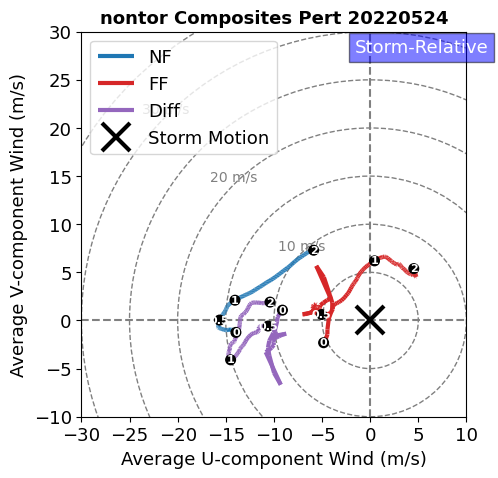

nf_srh-ff_srh = 81.06520805041403
20230609
20230611
20230612
20230613
20240427
20240501
20240502
20240504
(196,)


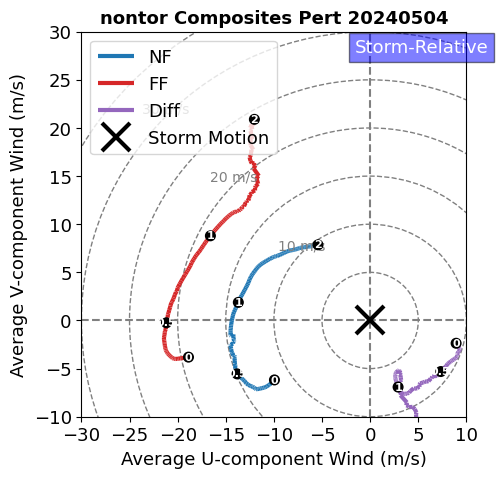

nf_srh-ff_srh = -226.17832065717698
20240528


In [53]:
nontor_winds, nontor_srh_df = srh_spatial_pert(comp_nontor_all, 'nontor')

(7,)
['20220524', '20230611', '20230613', '20240427', '20240501', '20240504', '20240528']
20220524
(196,)


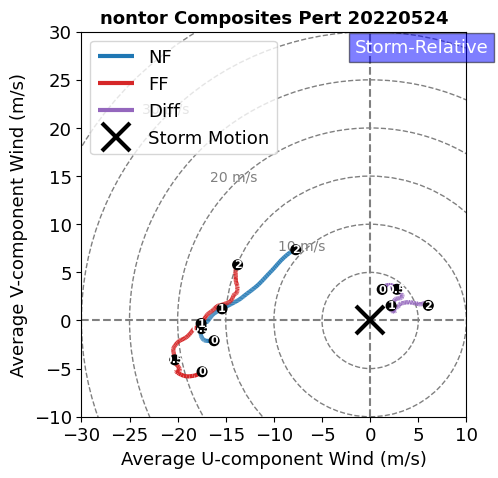

nf_srh-ff_srh = -47.77342337495264
20230611
20230613
20240427
20240501
20240504
(196,)


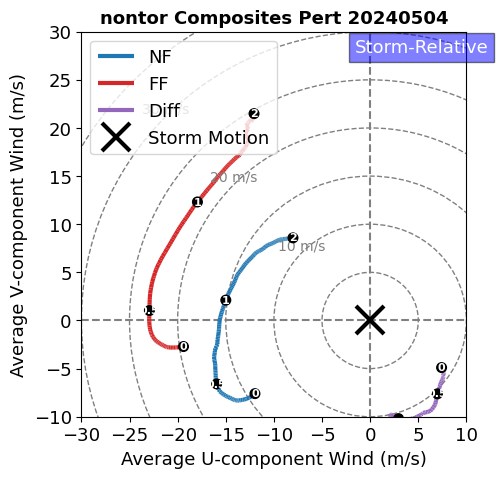

nf_srh-ff_srh = -283.03114496658566
20240528


In [54]:
nontor_winds_new, nontor_srh_df_new = srh_spatial_pert(comp_nontor_all_new, 'nontor')

In [ ]:
nontor_winds_new

In [ ]:
nontor_srh_df_new

(4,)
['20220523', '20230524', '20230527', '20230615']
20220523
(196,)


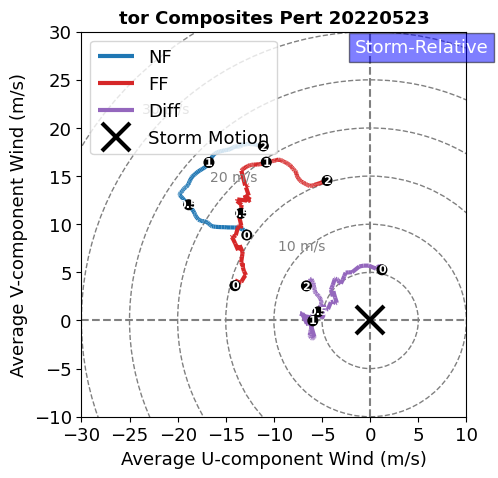

nf_srh-ff_srh = -60.837827017564535
20230524
(196,)


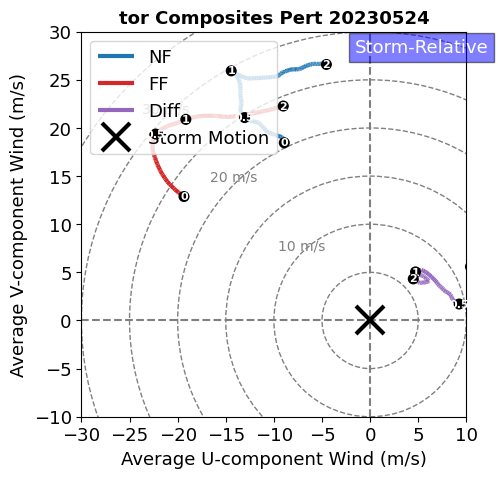

nf_srh-ff_srh = -195.22431051480666
20230527
(196,)


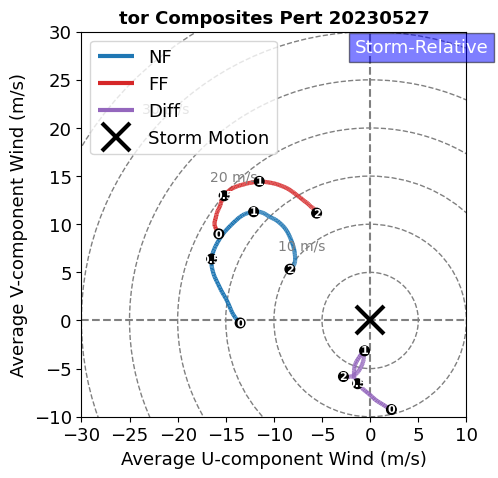

nf_srh-ff_srh = 4.630424664435793
20230615
(196,)


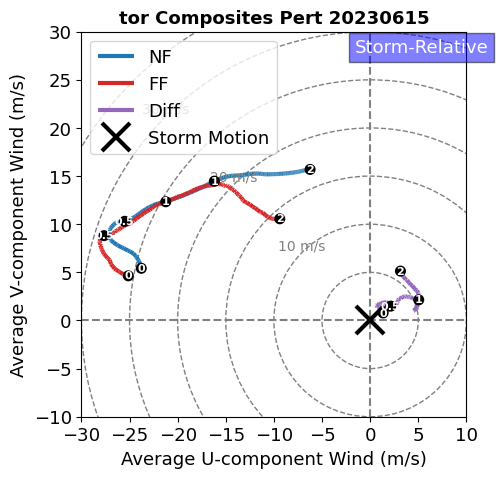

nf_srh-ff_srh = 92.96911006099401


In [55]:
tor_winds, tor_srh_df = srh_spatial_pert(comp_tor_all, 'tor')

In [ ]:
tor_srh_df

(5,)
['20220523', '20230524', '20230527', '20230615', '20240502']
20220523
(196,)


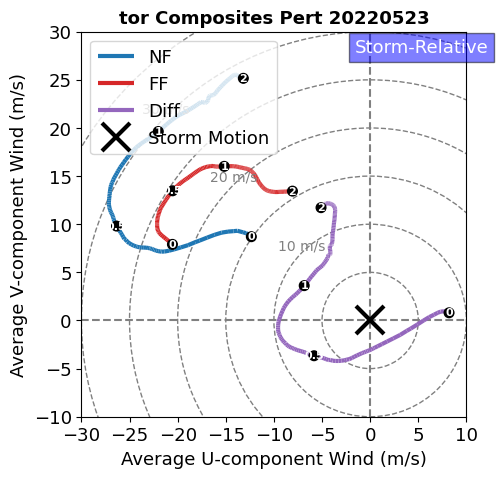

nf_srh-ff_srh = 226.253871170021
20230524
(196,)


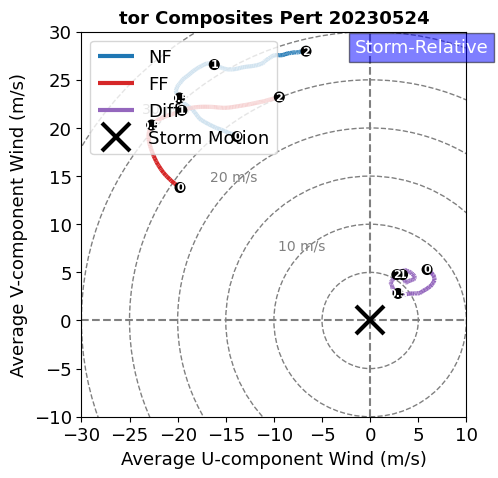

nf_srh-ff_srh = -66.49263337893467
20230527
(196,)


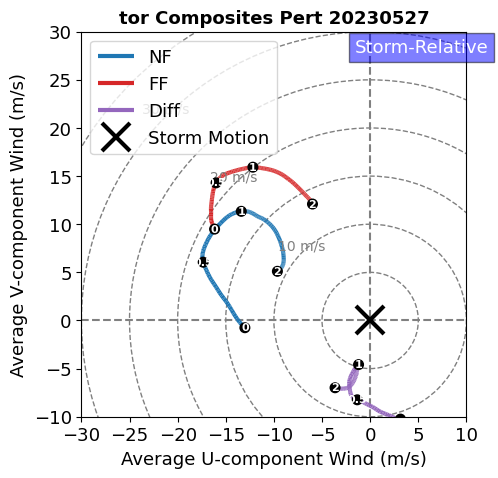

nf_srh-ff_srh = -24.82010480006622
20230615
(196,)


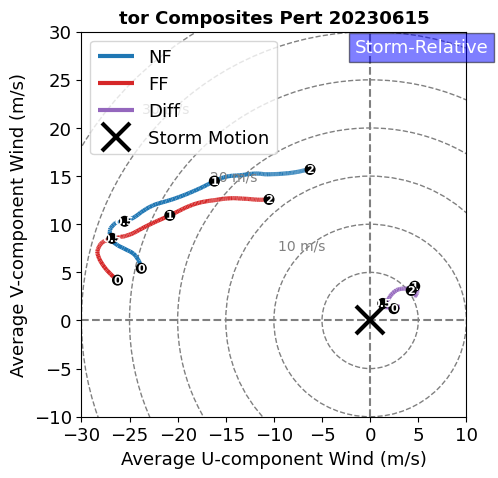

nf_srh-ff_srh = 93.45984165845266
20240502


In [56]:
tor_winds_new, tor_srh_df_new = srh_spatial_pert(comp_tor_all_new, 'tor')

In [ ]:
tor_winds_new

In [ ]:
tor_srh_df_new 

In [134]:
dates_eh = sorted(set(comp_tor_all_nodist['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all_nodist[comp_tor_all_nodist['date'] == d]
    
    if (comp_date['label'].eq('pretor').any()) and (comp_date['label'].eq('dtor').any()):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)

        pre_u0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :1].values, axis=0)
        pre_v0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :1].values, axis=0)
        
        pre_u500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :50].values, axis=0)
        pre_v500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :50].values, axis=0)
        
        pre_u1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :100].values, axis=0)
        pre_v1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :100].values, axis=0)
        
        pre_u = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :196].values, axis=0)
        pre_v = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :196].values, axis=0)

        d_u0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :1].values, axis=0)
        d_v0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :1].values, axis=0)

        d_u500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :50].values, axis=0)
        d_v500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :50].values, axis=0)

        d_u1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :100].values, axis=0)
        d_v1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :100].values, axis=0)

        d_u = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :196].values, axis=0)
        d_v = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :196].values, axis=0)
    
        # pre_delta_u = pre_u_ff - pre_u_nf
        # pre_delta_v = pre_v_ff - pre_v_nf

        # d_delta_u = d_u_ff - d_u_nf
        # d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_u_ser = pd.Series(pre_u)
        pre_v_ser = pd.Series(pre_v)

        d_u_ser = pd.Series(d_u)
        d_v_ser = pd.Series(d_v)

        pre_srw0 = comp_srw(pre_u_ser, pre_v_ser, 0)
        pre_srw500 = comp_srw(pre_u_ser, pre_v_ser, 50)
        pre_srw1 = comp_srw(pre_u_ser, pre_v_ser, 100)
        pre_srw2 = comp_srw(pre_u_ser, pre_v_ser, 194)

        d_srw0 = comp_srw(d_u_ser, d_v_ser, 0)
        d_srw500 = comp_srw(d_u_ser, d_v_ser, 50)
        d_srw1 = comp_srw(d_u_ser, d_v_ser, 100)
        d_srw2 = comp_srw(d_u_ser, d_v_ser, 194)
        
        pre_srh0 = comp_srh_nan(pre_u0, pre_v0)
        pre_srh500 = comp_srh_nan(pre_u500, pre_v500)
        pre_srh1 = comp_srh_nan(pre_u1, pre_v1)
        pre_srh2 = comp_srh_nan(pre_u, pre_v)
        #pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_srh0 = comp_srh_nan(d_u0, d_v0)
        d_srh500 = comp_srh_nan(d_u500, d_v500)
        d_srh1 = comp_srh_nan(d_u1, d_v1)
        d_srh2 = comp_srh_nan(d_u, d_v)
        #d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        #pre_delta_srh = pre_nf_srh - pre_ff_srh
        #d_delta_srh = d_nf_srh - d_ff_srh

        pre_d_delta_srw0 = d_srw0 - pre_srw0
        pre_d_delta_srw500 = d_srw500 - pre_srw500
        pre_d_delta_srw1 = d_srw1 - pre_srw1
        pre_d_delta_srw2 = d_srw2 - pre_srw2
        
        pre_d_delta_srh0 = d_srh0 - pre_srh0
        pre_d_delta_srh500 = d_srh500 - pre_srh500
        pre_d_delta_srh1 = d_srh1 - pre_srh1
        pre_d_delta_srh2 = d_srh2 - pre_srh2
        #print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]

        tor_srh['PRE_SFC_SRW'] = [pre_srw0]
        tor_srh['PRE_0-500m_SRW'] = [pre_srw500]
        tor_srh['PRE_0-1km_SRW'] = [pre_srw1]
        tor_srh['PRE_0-2km_SRW'] = [pre_srw2]

        tor_srh['PRE_0-500m_SRH'] = [pre_srh500]
        tor_srh['PRE_0-1km_SRH'] = [pre_srh1]
        tor_srh['PRE_0-2km_SRH'] = [pre_srh2]
        #tor_srh['PRE_FF_SRH'] = [pre_ff_srh]

        tor_srh['D_SFC_SRW'] = [d_srw0]
        tor_srh['D_0-500m_SRW'] = [d_srw500]
        tor_srh['D_0-1km_SRW'] = [d_srw1]
        tor_srh['D_0-2km_SRW'] = [d_srw2]

        tor_srh['D_0-500m_SRH'] = [d_srh500]
        tor_srh['D_0-1km_SRH'] = [d_srh1]
        tor_srh['D_0-2km_SRH'] = [d_srh2]
        #tor_srh['D_0-2km_SRH'] = [d_srh2]
        #tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        #tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        #tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        tor_srh['D_minus_PRE_SFC_SRW'] = [pre_d_delta_srw0]
        tor_srh['D_minus_PRE_0-500m_SRW'] = [pre_d_delta_srw500]
        tor_srh['D_minus_PRE_0-1km_SRW'] = [pre_d_delta_srw1]
        tor_srh['D_minus_PRE_0-2km_SRW'] = [pre_d_delta_srw2]

        tor_srh['D_minus_PRE_0-500m_SRH'] = [pre_d_delta_srh500]
        tor_srh['D_minus_PRE_0-1km_SRH'] = [pre_d_delta_srh1]
        tor_srh['D_minus_PRE_0-2km_SRH'] = [pre_d_delta_srh2]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

20220523
20230527
20230615


In [135]:
septor_srh_df

,Date,PRE_SFC_SRW,PRE_0-500m_SRW,PRE_0-1km_SRW,PRE_0-2km_SRW,PRE_0-500m_SRH,PRE_0-1km_SRH,PRE_0-2km_SRH,D_SFC_SRW,D_0-500m_SRW,...,D_0-500m_SRH,D_0-1km_SRH,D_0-2km_SRH,D_minus_PRE_SFC_SRW,D_minus_PRE_0-500m_SRW,D_minus_PRE_0-1km_SRW,D_minus_PRE_0-2km_SRW,D_minus_PRE_0-500m_SRH,D_minus_PRE_0-1km_SRH,D_minus_PRE_0-2km_SRH
0,20220523,11.391370,19.887864,18.859404,15.520907,94.844462,154.524257,193.831606,17.846591,21.059649,...,52.953707,128.195210,201.481112,6.455221,1.171785,2.095145,1.003148,-41.890755,-26.329046,7.649506
0,20230527,19.347312,21.575938,19.390932,13.267284,99.578278,180.075214,245.252639,15.902228,21.019864,...,126.412802,286.314231,263.676120,-3.445084,-0.556074,-0.543933,-0.373903,26.834525,106.239017,18.423481
0,20230615,25.269393,27.874844,22.593379,11.213294,37.308496,122.857374,161.040361,31.233586,37.162304,...,58.767601,623.059975,1050.558900,5.964193,9.287460,16.356916,28.796614,21.459105,500.202602,889.518539


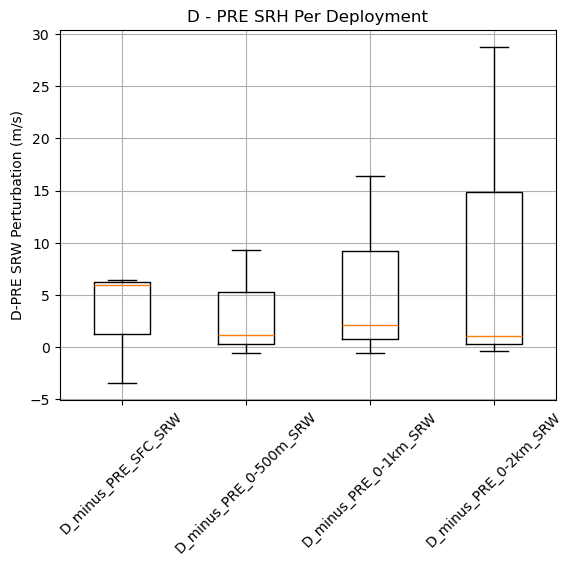

In [140]:
#label = 'D_minus_PRE_SRH'
plt.boxplot([septor_srh_df['D_minus_PRE_SFC_SRW'], septor_srh_df['D_minus_PRE_0-500m_SRW'], 
             septor_srh_df['D_minus_PRE_0-1km_SRW'], septor_srh_df['D_minus_PRE_0-2km_SRW']],
           labels = ['D_minus_PRE_SFC_SRW','D_minus_PRE_0-500m_SRW', 'D_minus_PRE_0-1km_SRW', 'D_minus_PRE_0-2km_SRW'])

plt.ylabel('D-PRE SRW Perturbation (m/s)')
plt.xticks(rotation = 45)
plt.title(f'D - PRE SRH Per Deployment')
plt.grid()
plt.show()

In [108]:
dates_eh = sorted(set(comp_tor_all['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all[comp_tor_all['date'] == d]
    
    if ((comp_date['label'].eq('pretor nf').any()) or (comp_date['label'].eq('pretor ff').any())) and ((comp_date['label'].eq('dtor nf').any()) or (comp_date['label'].eq('dtor ff').any())):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)
        
        pre_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)
        pre_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)

        d_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
        d_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
    
        pre_delta_u = pre_u_ff - pre_u_nf
        pre_delta_v = pre_v_ff - pre_v_nf

        d_delta_u = d_u_ff - d_u_nf
        d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_nf_srh = comp_srh_nan(pre_u_nf, pre_v_nf)
        pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_nf_srh = comp_srh_nan(d_u_nf, d_v_nf)
        d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        pre_delta_srh = pre_nf_srh - pre_ff_srh
        d_delta_srh = d_nf_srh - d_ff_srh
        
        #print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['PRE_NF_SRH'] = [pre_nf_srh]
        tor_srh['PRE_FF_SRH'] = [pre_ff_srh]
        
        tor_srh['D_NF_SRH'] = [d_nf_srh]
        tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

20220523
20230527
20230615


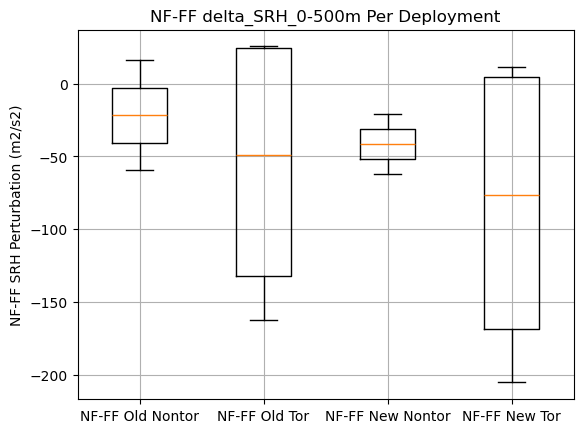

In [57]:
label = 'delta_SRH_0-500m'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

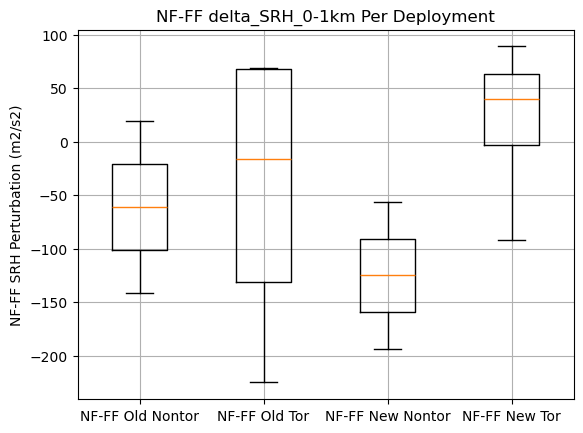

In [43]:
label = 'delta_SRH_0-1km'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

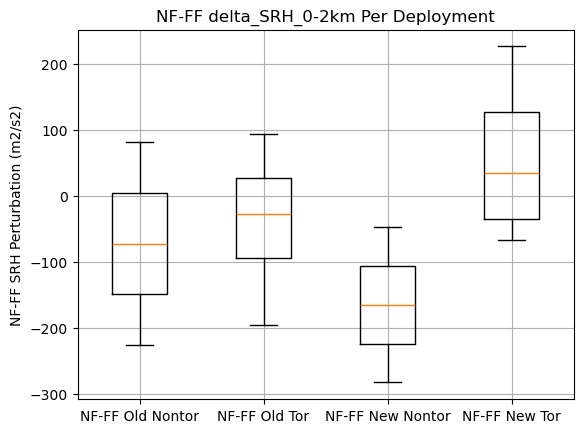

In [44]:
label = 'delta_SRH_0-2km'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

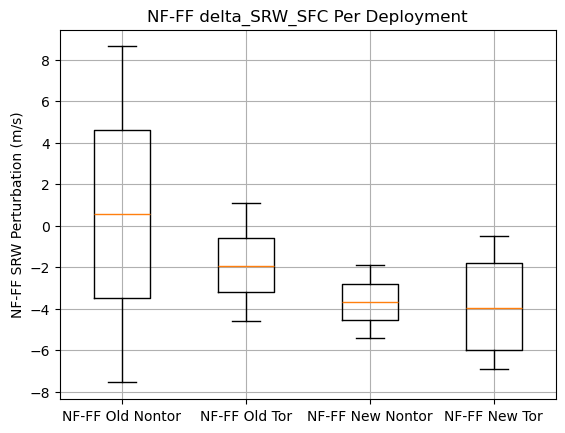

In [64]:
label = 'delta_SRW_SFC'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

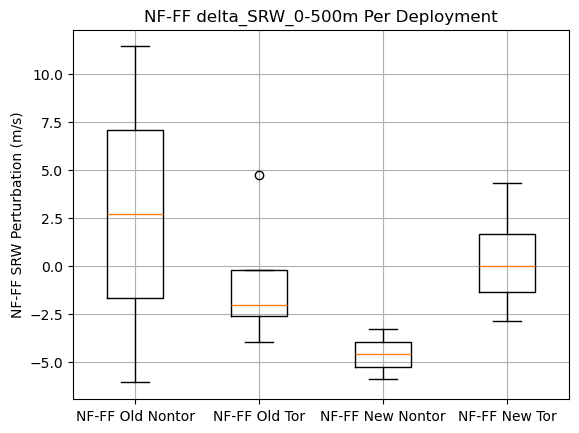

In [63]:
label = 'delta_SRW_0-500m'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

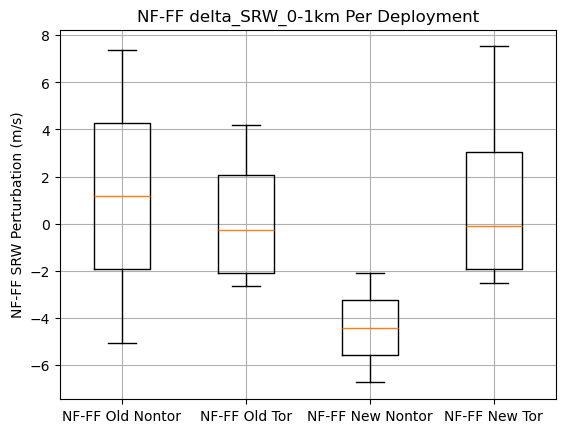

In [62]:
label = 'delta_SRW_0-1km'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

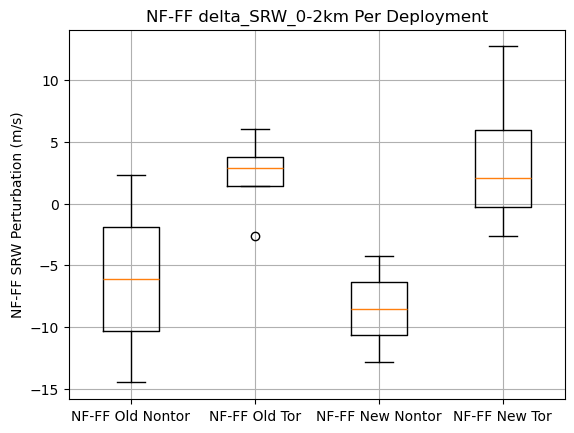

In [65]:
label = 'delta_SRW_0-2km'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

# Permutation Test (test for statistical significance

Doing a permutation test shuffles the data randomly to see if the calculated test result is similar or not regardless of how the data is sorted (meaning there is not much difference in the data itself). Fot us, the test result that we're checking is the difference between the means of our nontornadic and tornadic nf-ff perturbation datasets.

In [182]:
from scipy.stats import permutation_test

In [185]:
np.array(nontor_srh_df_new[label])

array([ -4.24551421, -12.8445152 ])

Sample size too small

In [218]:
label = 'delta_SRW_0-2km'
result = permutation_test((tor_srh_df_new[label], nontor_srh_df_new[label]), test_stat, permutation_type='independent')

In [219]:
result

PermutationTestResult(statistic=12.120212163749384, pvalue=0.13333333333333333, null_distribution=array([ 12.12021216,   8.57929028,   2.13003954,  10.9183479 ,
         4.46909716,   0.92817528,   6.144175  ,  -0.30507574,
        -3.84599762,  -1.50694   ,  -0.62309955,  -7.07235029,
       -10.61327217,  -8.27421455, -13.04838745]))

# Avg u and v SRW and SRH per VAD

SRW

Does this even mean anything? The average u and v component from 0-2km?

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
        
    tor_u_nf_per = np.nanmean(nf_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_nf_per = np.nanmean(nf_v_categories['tor'].iloc[:, h0:htop], axis=1)
    
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    tor_u_ff_per = np.nanmean(ff_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_ff_per = np.nanmean(ff_v_categories['tor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
avg_sfc_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 0, 5)
avg_500m_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 50, 55)
avg_1km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 100, 105)
avg_2km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 191, 196)

In [ ]:
avg_sfc_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 0, 5)
avg_500m_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 50, 55)
avg_1km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 100, 105)
avg_2km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 191, 196)

In [ ]:
np.shape(avg_sfc_wind['pretor_u_nf_per'])

In [ ]:
def tor_boxplot_uandv(data_dict, title_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height['nontor_u_nf_per'], height['tor_u_nf_per'], height['pretor_u_nf_per'], height['dtor_u_nf_per'], 
                 height['posttor_u_nf_per']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title_height} Storm-Relative Wind u Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height['nontor_v_nf_per'], height['tor_v_nf_per'], height['pretor_v_nf_per'], height['dtor_v_nf_per'], 
                 height['posttor_v_nf_per']], labels = labels)
    
    ax1.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title_height} Storm-Relative Wind v Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_uandv(avg_sfc_wind, '50m')

In [ ]:
tor_boxplot_uandv(avg_sfc_wind_new, '50m NEW')

In [ ]:
tor_boxplot_uandv(avg_500m_wind, '500m')

In [ ]:
tor_boxplot_uandv(avg_500m_wind_new, '500m NEW')

In [ ]:
tor_boxplot_uandv(avg_1km_wind, '1km')

In [ ]:
tor_boxplot_uandv(avg_1km_wind_new, '1km NEW')

In [ ]:
tor_boxplot_uandv(avg_2km_wind, '2km')

In [ ]:
tor_boxplot_uandv(avg_2km_wind_new, '2km NEW')

0-xkm Shear Vector Magnitudes

# SRH and SRW of u and v categories big breakdown (with boxplots)

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
def shear_magnitude(u, v, vector_height):
    delta_u = u.iloc[:, vector_height] - u.iloc[:, 0]
    delta_v = v.iloc[:, vector_height] - v.iloc[:, 0]
    mag = np.sqrt(np.nansum([(delta_u**2), (delta_v**2)], axis=0))

    return mag

In [ ]:
def shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, vector_height):

    nf_tor = shear_magnitude(nf_u_categories['tor'], nf_v_categories['tor'], vector_height)
    ff_tor = shear_magnitude(ff_u_categories['tor'], ff_v_categories['tor'], vector_height)

    nf_pretor = shear_magnitude(nf_u_categories['pretor'], nf_v_categories['pretor'], vector_height)
    ff_pretor = shear_magnitude(ff_u_categories['pretor'], ff_v_categories['pretor'], vector_height)

    nf_dtor = shear_magnitude(nf_u_categories['dtor'], nf_v_categories['dtor'], vector_height)
    ff_dtor = shear_magnitude(ff_u_categories['dtor'], ff_v_categories['dtor'], vector_height)

    nf_posttor = shear_magnitude(nf_u_categories['posttor'], nf_v_categories['posttor'], vector_height)
    ff_posttor = shear_magnitude(ff_u_categories['posttor'], ff_v_categories['posttor'], vector_height)

    nf_nontor = shear_magnitude(nf_u_categories['nontor'], nf_v_categories['nontor'], vector_height)
    ff_nontor = shear_magnitude(ff_u_categories['nontor'], ff_v_categories['nontor'], vector_height)

    return locals()

In [ ]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [ ]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [ ]:
def srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srh(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srh(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srh(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srh(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srh(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srh(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srh(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srh(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srh(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srh(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
def srw_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srw(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srw(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srw(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srw(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srw(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srw(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srw(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srw(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srw(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srw(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
angle0to30_nf = np.array(nf_u_categories_new['Angle']) < 31
a = nf_u_categories['pretor'][angle0to30_nf]

In [ ]:
srh_all = srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories)

In [ ]:
srh_all_new = srh_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
def srh_per_level(srh_all):

    nf_tor_sfcto500 = np.nansum(srh_all['nf_tor'][:50], axis=0)
    nf_tor_sfcto1km = np.nansum(srh_all['nf_tor'][:100], axis=0)
    nf_tor_sfcto1halfkm = np.nansum(srh_all['nf_tor'][:150], axis=0)
    nf_tor_sfcto2km = np.nansum(srh_all['nf_tor'][:196], axis=0)

    ff_tor_sfcto500 = np.nansum(srh_all['ff_tor'][:50], axis=0)
    ff_tor_sfcto1km = np.nansum(srh_all['ff_tor'][:100], axis=0)
    ff_tor_sfcto1halfkm = np.nansum(srh_all['ff_tor'][:150], axis=0)
    ff_tor_sfcto2km = np.nansum(srh_all['ff_tor'][:196], axis=0)
    
    nf_pretor_sfcto500 = np.nansum(srh_all['nf_pretor'][:50], axis=0)
    nf_pretor_sfcto1km = np.nansum(srh_all['nf_pretor'][:100], axis=0)
    nf_pretor_sfcto1halfkm = np.nansum(srh_all['nf_pretor'][:150], axis=0)
    nf_pretor_sfcto2km = np.nansum(srh_all['nf_pretor'][:196], axis=0)

    ff_pretor_sfcto500 = np.nansum(srh_all['ff_pretor'][:50], axis=0)
    ff_pretor_sfcto1km = np.nansum(srh_all['ff_pretor'][:100], axis=0)
    ff_pretor_sfcto1halfkm = np.nansum(srh_all['ff_pretor'][:150], axis=0)
    ff_pretor_sfcto2km = np.nansum(srh_all['ff_pretor'][:196], axis=0)

    nf_dtor_sfcto500 = np.nansum(srh_all['nf_dtor'][:50], axis=0)
    nf_dtor_sfcto1km = np.nansum(srh_all['nf_dtor'][:100], axis=0)
    nf_dtor_sfcto1halfkm = np.nansum(srh_all['nf_dtor'][:150], axis=0)
    nf_dtor_sfcto2km = np.nansum(srh_all['nf_dtor'][:196], axis=0)

    ff_dtor_sfcto500 = np.nansum(srh_all['ff_dtor'][:50], axis=0)
    ff_dtor_sfcto1km = np.nansum(srh_all['ff_dtor'][:100], axis=0)
    ff_dtor_sfcto1halfkm = np.nansum(srh_all['ff_dtor'][:150], axis=0)
    ff_dtor_sfcto2km = np.nansum(srh_all['ff_dtor'][:196], axis=0)

    nf_posttor_sfcto500 = np.nansum(srh_all['nf_posttor'][:50], axis=0)
    nf_posttor_sfcto1km = np.nansum(srh_all['nf_posttor'][:100], axis=0)
    nf_posttor_sfcto1halfkm = np.nansum(srh_all['nf_posttor'][:150], axis=0)
    nf_posttor_sfcto2km = np.nansum(srh_all['nf_posttor'][:196], axis=0)

    ff_posttor_sfcto500 = np.nansum(srh_all['ff_posttor'][:50], axis=0)
    ff_posttor_sfcto1km = np.nansum(srh_all['ff_posttor'][:100], axis=0)
    ff_posttor_sfcto1halfkm = np.nansum(srh_all['ff_posttor'][:150], axis=0)
    ff_posttor_sfcto2km = np.nansum(srh_all['ff_posttor'][:196], axis=0)

    nf_nontor_sfcto500 = np.nansum(srh_all['nf_nontor'][:50], axis=0)
    nf_nontor_sfcto1km = np.nansum(srh_all['nf_nontor'][:100], axis=0)
    nf_nontor_sfcto1halfkm = np.nansum(srh_all['nf_nontor'][:150], axis=0)
    nf_nontor_sfcto2km = np.nansum(srh_all['nf_nontor'][:196], axis=0)

    ff_nontor_sfcto500 = np.nansum(srh_all['ff_nontor'][:50], axis=0)
    ff_nontor_sfcto1km = np.nansum(srh_all['ff_nontor'][:100], axis=0)
    ff_nontor_sfcto1halfkm = np.nansum(srh_all['ff_nontor'][:150], axis=0)
    ff_nontor_sfcto2km = np.nansum(srh_all['ff_nontor'][:196], axis=0)

    return locals()

In [ ]:
srh_sum_all = srh_per_level(srh_all)

In [ ]:
srh_sum_all_new = srh_per_level(srh_all_new)

In [ ]:
mag_all_500m = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 51)
mag_all_1km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 101)
mag_all_2km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 195)

In [ ]:
mag_all_500m_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 51)
mag_all_1km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 101)
mag_all_2km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 195)

In [ ]:
srw_all_new = srw_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
angle0to30_nf = nf_u_categories_new['Angle'] < 31
angle0to30_ff = ff_u_categories_new['Angle'] < 31
angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]

mag_all_500m_new_0to30 = shear_mag_all_cats(nf_u_categories_new[angle0to30_nf] , 
                                            nf_v_categories_new[angle0to30_nf], 
                                            ff_u_categories_new[angle0to30_ff], 
                                            ff_v_categories_new[angle0to30_ff], 51)

mag_all_500m_new_30to60 = shear_mag_all_cats(nf_u_categories_new[angle30to60_nf], nf_v_categories_new[angle30to60_nf], 
                                            ff_u_categories_new[angle30to60_ff], ff_v_categories_new[angle30to60_ff], 51)

mag_all_2km_new_60to90 = shear_mag_all_cats(nf_u_categories_new[angle600to90_nf], nf_v_categories_new[angle600to90_nf], 
                                            ff_u_categories_new[angle600to90_ff], ff_v_categories_new[angle600to90_ff], 51)

In [ ]:
def tor_boxplot_srh(data_dict, title_height, srh_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height[f'nf_nontor_sfcto{srh_height}'], height[f'nf_tor_sfcto{srh_height}'], height[f'nf_pretor_sfcto{srh_height}'], 
                 height[f'nf_dtor_sfcto{srh_height}'], height[f'nf_posttor_sfcto{srh_height}']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'0-{title_height} Storm-Relative Helicity Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height[f'ff_nontor_sfcto{srh_height}'], height[f'ff_tor_sfcto{srh_height}'], height[f'ff_pretor_sfcto{srh_height}'], 
                 height[f'ff_dtor_sfcto{srh_height}'], height[f'ff_posttor_sfcto{srh_height}']], labels = labels)
    
    ax1.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'0-{title_height} Storm-Relative Helicity Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_srh(srh_sum_all, '500m', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '500m NEW', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all, '1km', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '1km NEW', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all, '2km', '2km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '2km NEW', '2km')

# Making SRH and SRW Columns for df_all_new

In [66]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [67]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [68]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [69]:
srw_all = []
srw_sfc = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    df_all_new.loc[df_u.index, 'SFC SRW Mag'] = srw_values_sfc  # Assign to correct indices
    df_all_new.loc[df_v.index, 'SFC SRW Mag'] = srw_values_sfc

    srw_values_500 = comp_srw(df_u, df_v, 49)
    
    df_all_new.loc[df_u.index, '0-500m SRW Mag'] = srw_values_500  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRW Mag'] = srw_values_500

    srw_values_1km = comp_srw(df_u, df_v, 100)
    
    df_all_new.loc[df_u.index, '0-1km SRW Mag'] = srw_values_1km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRW Mag'] = srw_values_1km

    srw_values_2km = comp_srw(df_u, df_v, 194)
    df_all_new.loc[df_u.index, '0-2km SRW Mag'] = srw_values_2km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRW Mag'] = srw_values_2km

In [70]:
srh_all = []
srh_0to2km = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    #print(range(len(df_u)))
    
    srh_values02 = [
        composite_srh_nan(df_u.iloc[i, :196], df_v.iloc[i, :196]) 
        for i in range(len(df_u))
    ]

    srh_values01 = [
        composite_srh_nan(df_u.iloc[i, :96], df_v.iloc[i, :96]) 
        for i in range(len(df_u))
    ]

    srh_values05 = [
        composite_srh_nan(df_u.iloc[i, :50], df_v.iloc[i, :50]) 
        for i in range(len(df_u))
    ]
    

    df_all_new.loc[df_u.index, '0-500m SRH'] = srh_values05  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRH'] = srh_values05
    
    df_all_new.loc[df_u.index, '0-1km SRH'] = srh_values01  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRH'] = srh_values01
    
    df_all_new.loc[df_u.index, '0-2km SRH'] = srh_values02  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRH'] = srh_values02


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/1549296991.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = np.nanprod([u[i+1], v[i]], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/1549296991.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = -np.nanprod([u[i], v[i+1]], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_49873/1549296991.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posi

# Seaborn Plots (SRH, SRW distributions)

## VAD Counts Per Value, Distance, etc.

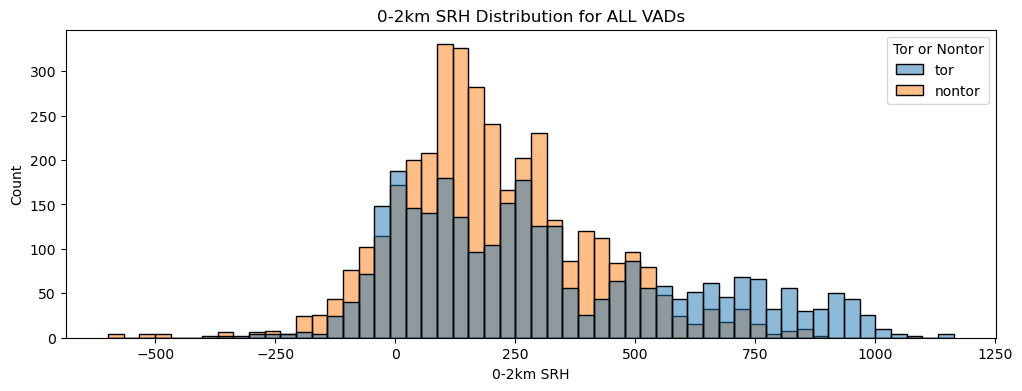

In [71]:
plt.figure(figsize = (12, 4))
sns.histplot(df_all_new, x = df_all_new['0-2km SRH'], hue = 'Tor or Nontor')
plt.title('0-2km SRH Distribution for ALL VADs')
plt.show()

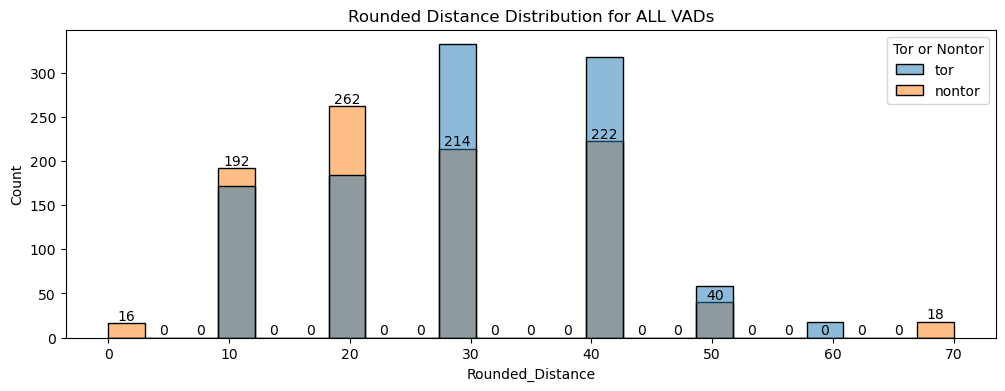

In [104]:
df = df_all_new
df = df[df['Distance'] <= 100]
df = df[df['Angle'] <= 90]

df['Rounded_Distance'] = df['Distance'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Distance'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Distance Distribution for ALL VADs')
plt.show()

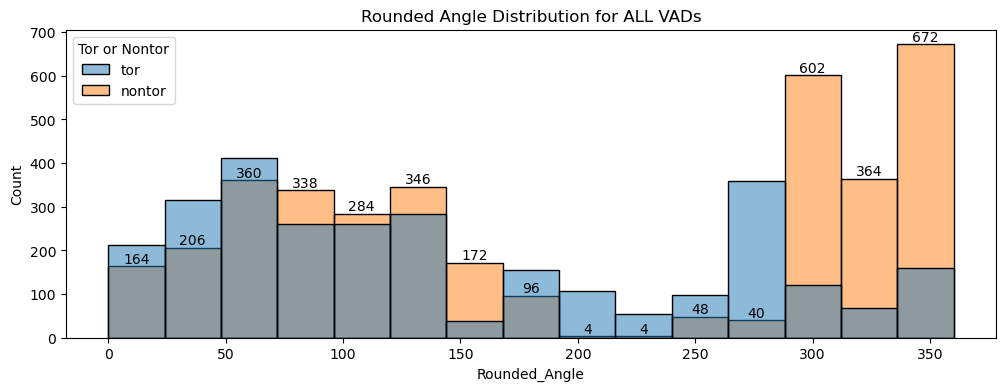

In [105]:
df = df_all_new
df['Rounded_Angle'] = df['Angle'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Angle'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Angle Distribution for ALL VADs')
plt.show()

## VAD SRH and SRW Distribution Based on Time from Tor

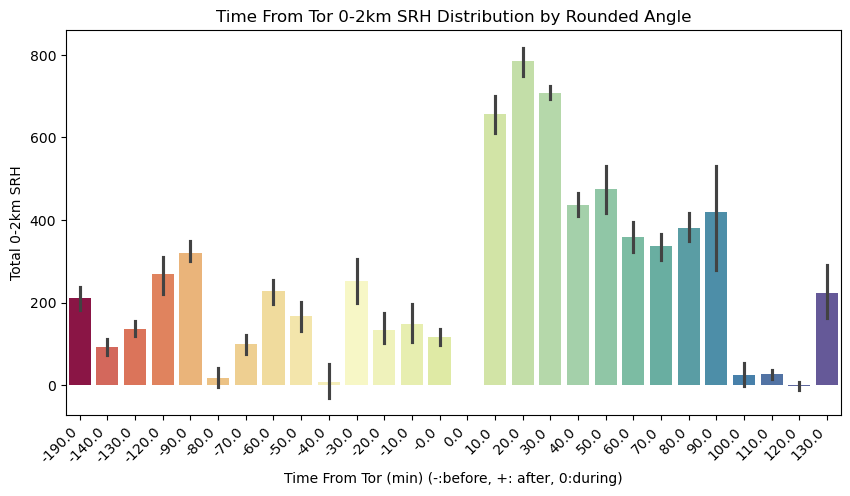

In [107]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SRH', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total 0-2km SRH")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total SFC SRW Mag")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

This may not be a good indication of wind speed differences; should look for the CHANGE in wind speed up to torgen, not just the raw srw speed because some days just have faster wind than others.

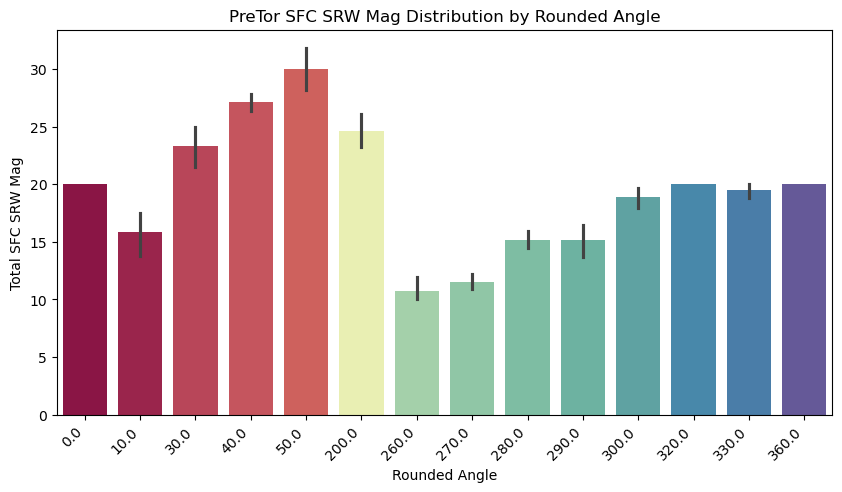

In [102]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PreTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

Rounded_Angle
250.0    38
170.0    32
240.0    28
180.0    28
230.0    24
160.0    16
0.0      12
220.0    10
190.0     8
110.0     8
360.0     6
30.0      6
80.0      4
260.0     4
210.0     4
120.0     2
350.0     2
Name: count, dtype: int64


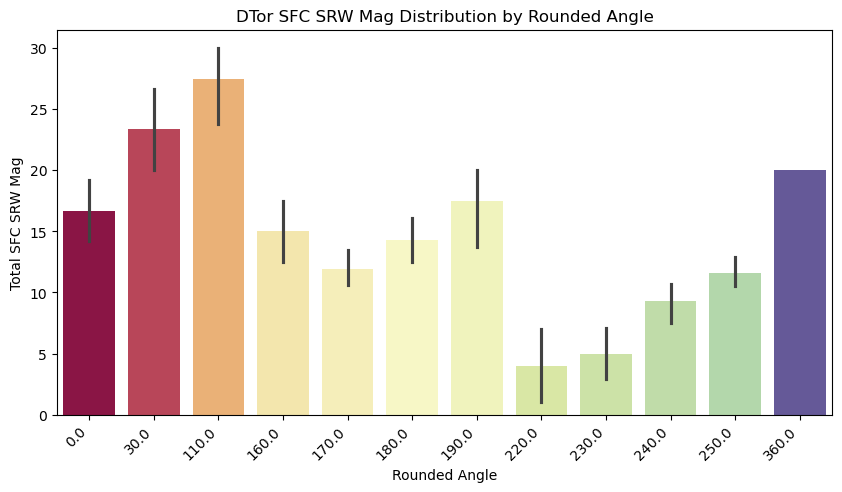

In [116]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
print(df['Rounded_Angle'].value_counts())
a = df['Rounded_Angle'].value_counts() >= 5
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("DTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

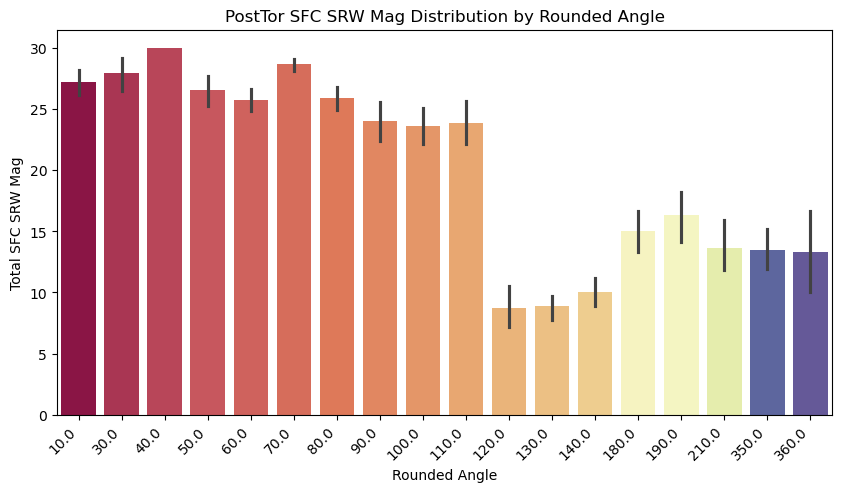

In [114]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) > 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PostTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

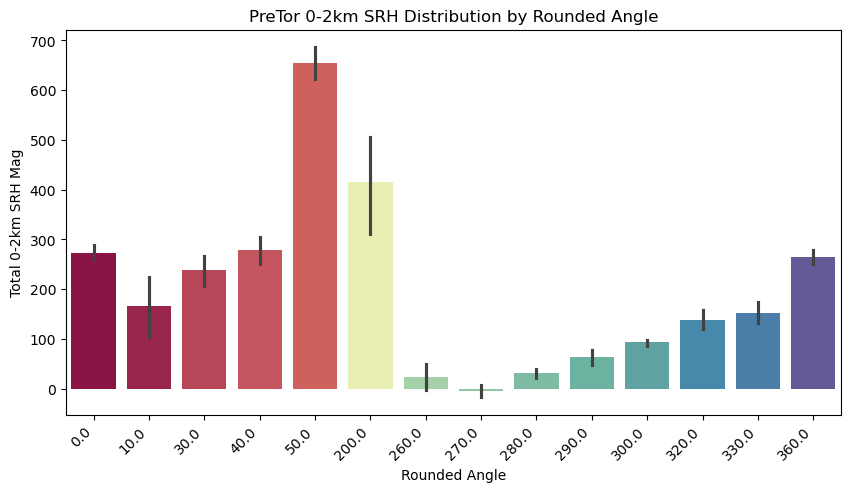

In [119]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total 0-2km SRH Mag")
plt.title("PreTor 0-2km SRH Distribution by Rounded Angle")
plt.show()

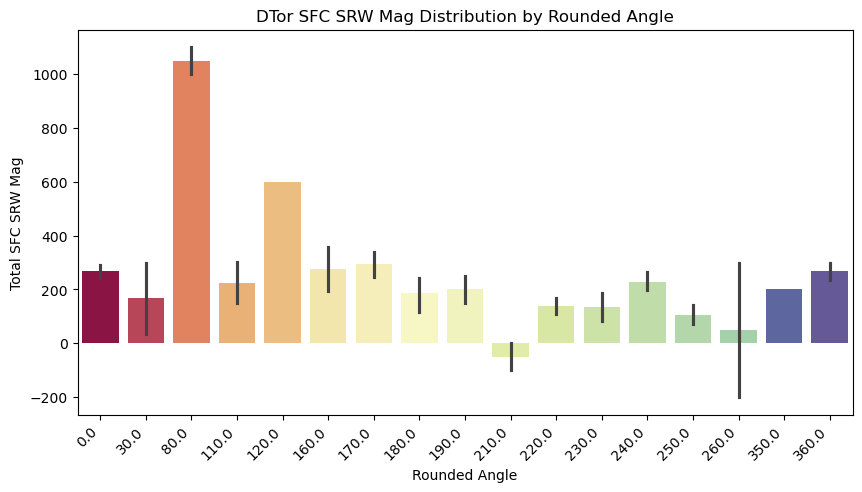

In [99]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) == 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("DTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

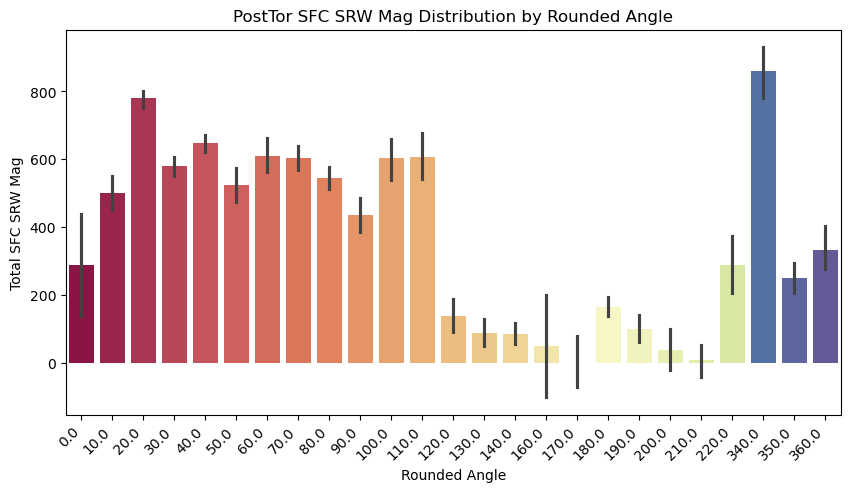

In [98]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) > 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PostTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

## VAD Distribution Based on Distance, Angle: Tor vs Nontor

In [75]:
def sns_barplot(df_all_new, field, tor_or_nontor, distance_or_angle, srw_or_srh, palette, figsize):
        
    df = df_all_new[df_all_new['Tor or Nontor'] == tor_or_nontor]

    df = df[df['Distance'] <= 100]
    df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif srw_or_srh == 'SRW':
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    plt.figure(figsize=figsize)
    sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, palette = palette)
    
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    plt.title(f'{tor_or_nontor} {field} Distribution by {distance_or_angle}')
    plt.show()

In [76]:
def sns_barplot_both(df_all_new, field, distance_or_angle, srw_or_srh, palette, figsize):
        
    df = df_all_new

    df = df[df['Distance'] <= 100]
    df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif srw_or_srh == 'SRW':
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    plt.figure(figsize=figsize)
    ax = sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, hue = 'Tor or Nontor', palette = palette)
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    plt.title(f'Tor vs Nontor {field} Distribution by {distance_or_angle}')
    plt.show()

In [ ]:
df_all_new

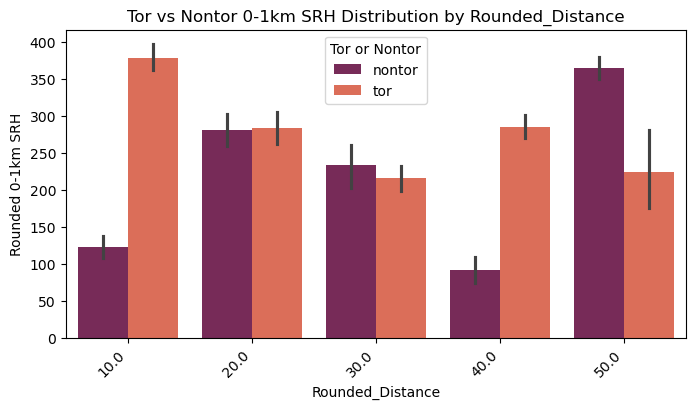

In [79]:
sns_barplot_both(df_all_new, '0-1km SRH', 'Rounded_Distance', 'SRH', 'rocket', (8,4))

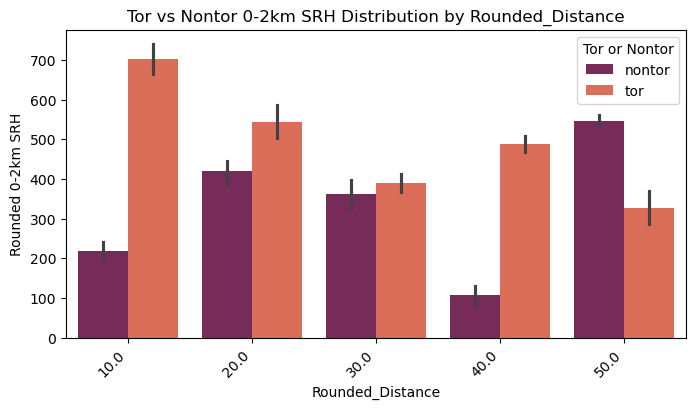

In [80]:
sns_barplot_both(df_all_new, '0-2km SRH', 'Rounded_Distance', 'SRH', 'rocket', (8,4))

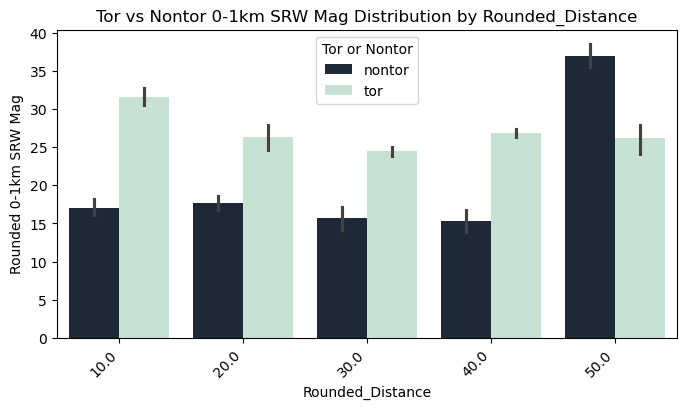

In [86]:
sns_barplot_both(df_all_new, '0-1km SRW Mag', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3_r', (8,4))

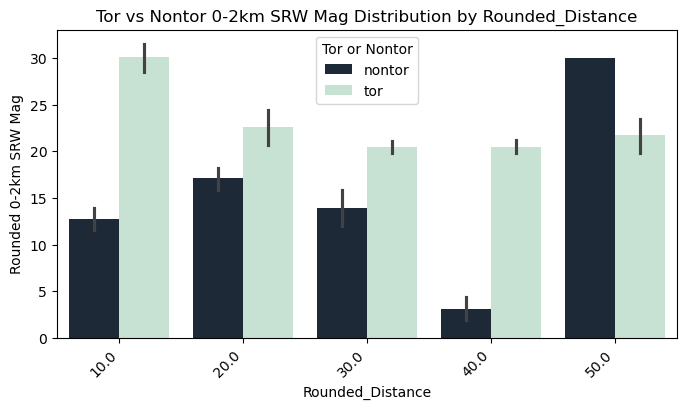

In [87]:
sns_barplot_both(df_all_new, '0-2km SRW Mag', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3_r', (8,4))

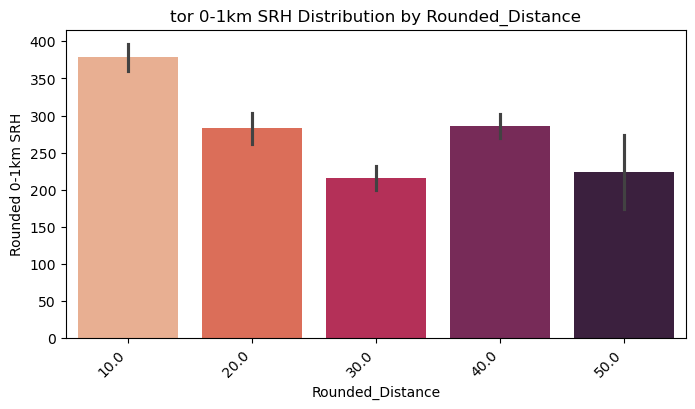

In [141]:
sns_barplot(df_all_new, '0-1km SRH', 'tor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

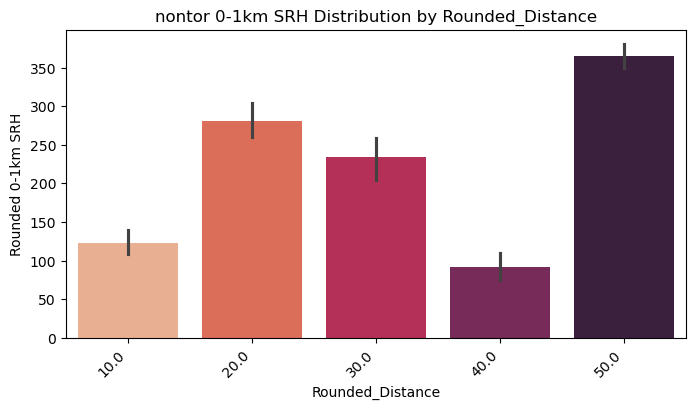

In [142]:
sns_barplot(df_all_new, '0-1km SRH', 'nontor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

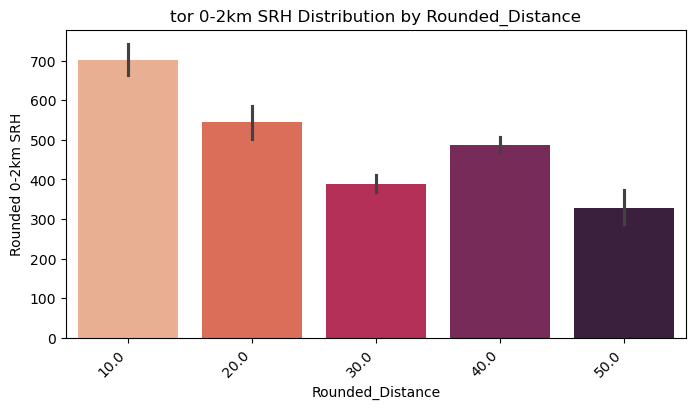

In [143]:
sns_barplot(df_all_new, '0-2km SRH', 'tor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

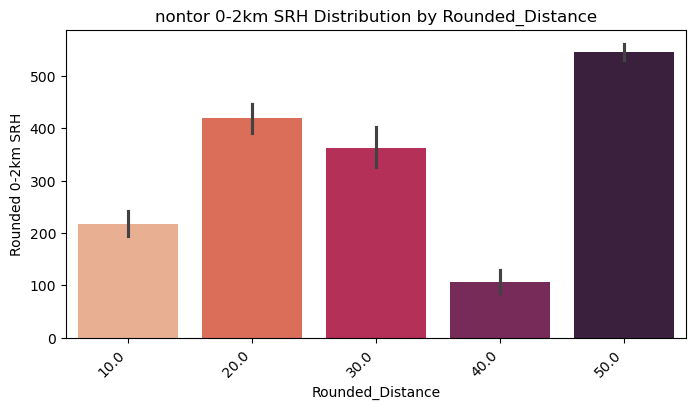

In [144]:
sns_barplot(df_all_new, '0-2km SRH', 'nontor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

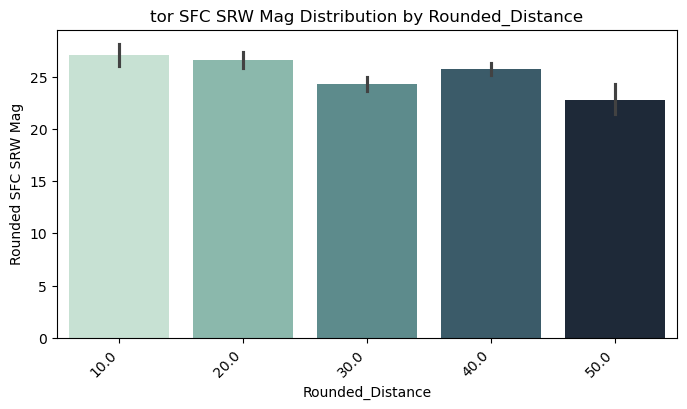

In [145]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'tor', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3', (8,4))

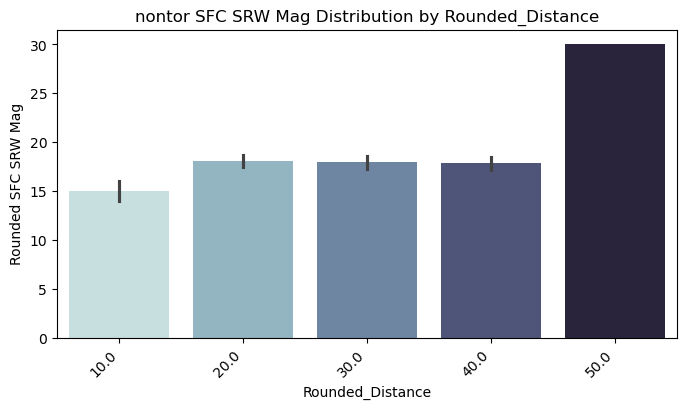

In [146]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'nontor', 'Rounded_Distance', 'SRW', "ch:start=.2,rot=-.3", (8,4))

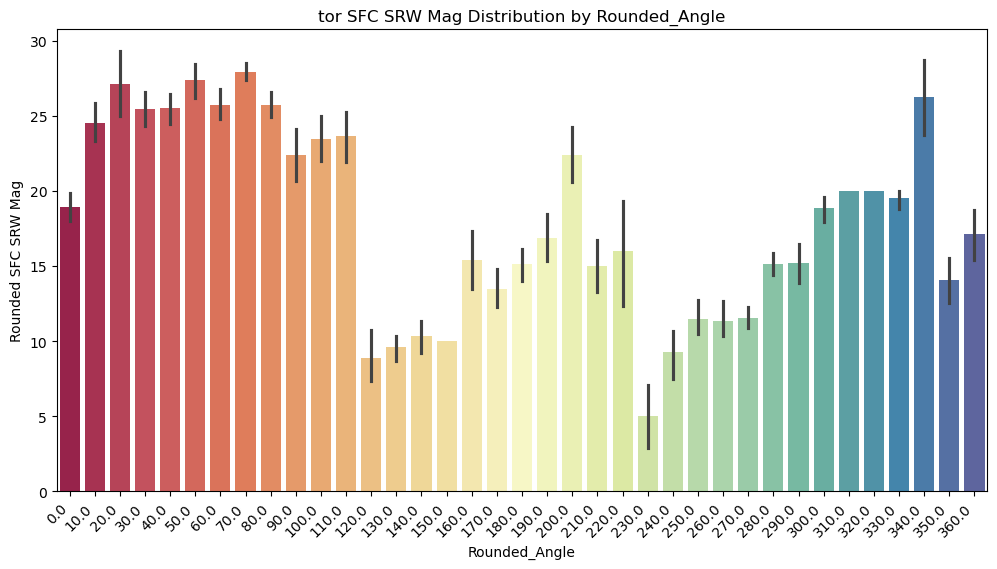

In [147]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'tor', 'Rounded_Angle', 'SRW', 'Spectral', (12,6))

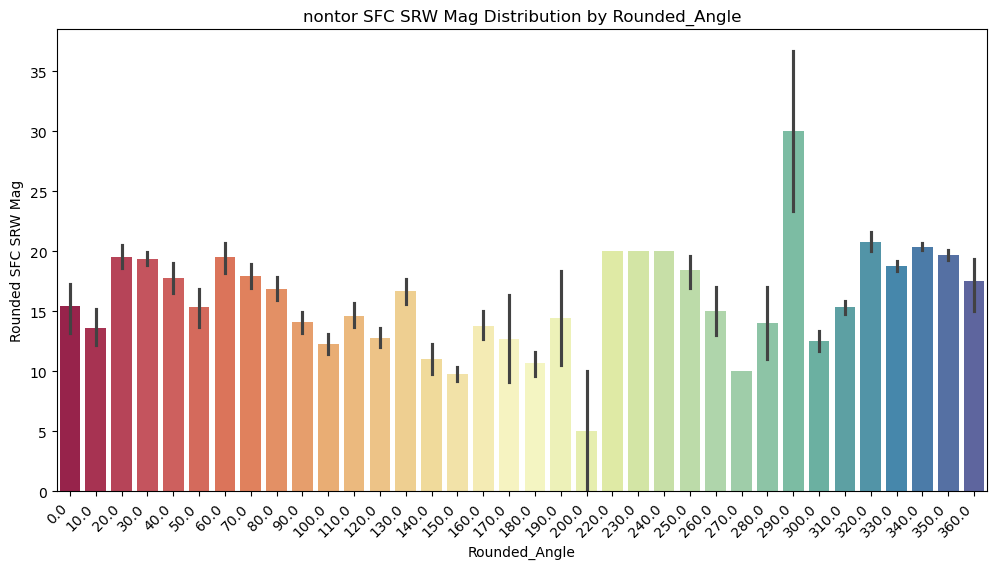

In [148]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'nontor', 'Rounded_Angle', 'SRW', 'Spectral', (12,6))

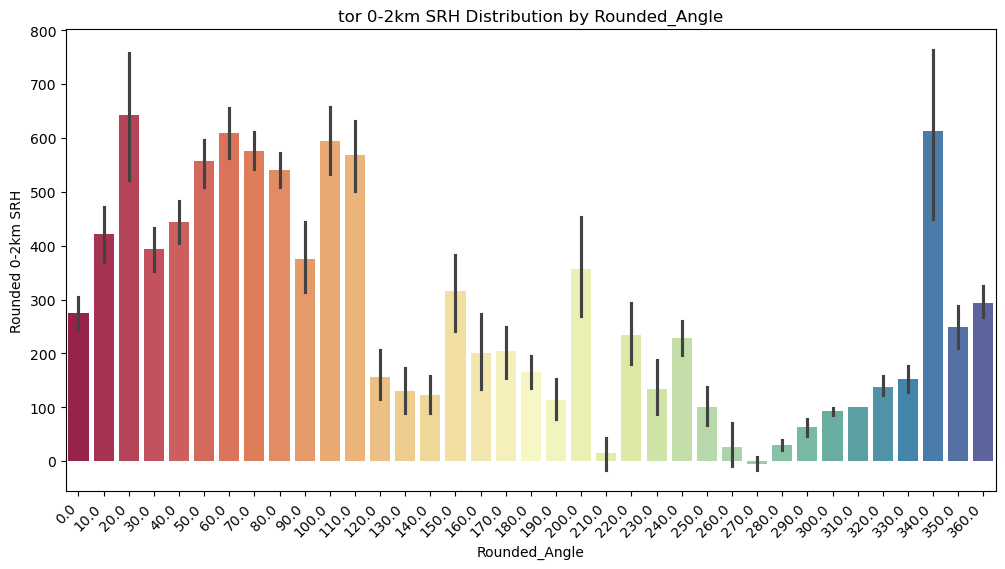

In [149]:
sns_barplot(df_all_new, '0-2km SRH', 'tor', 'Rounded_Angle', 'SRH', 'Spectral', (12,6))

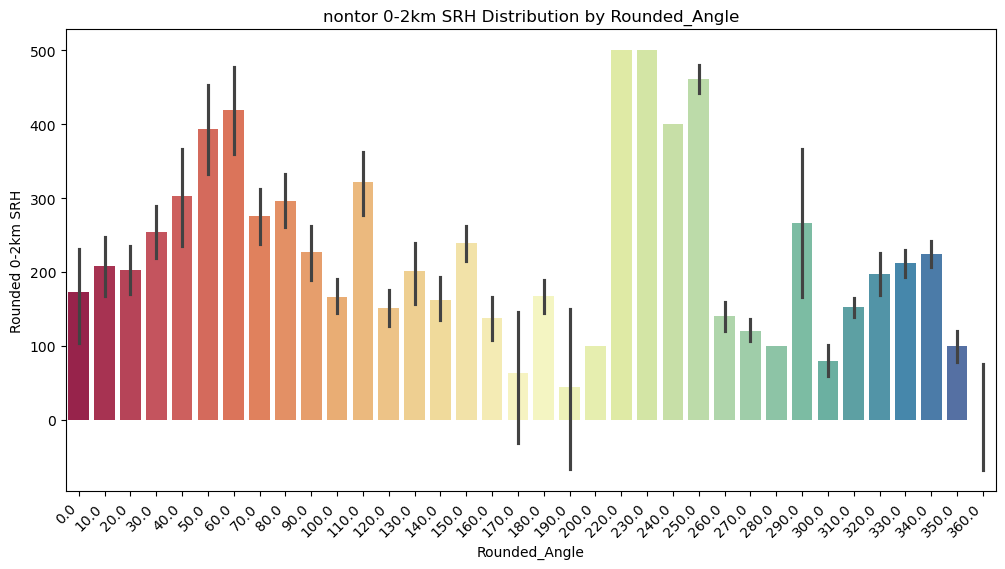

In [150]:
sns_barplot(df_all_new, '0-2km SRH', 'nontor', 'Rounded_Angle', 'SRH', 'Spectral', (12,6))

# KDE Distributions

In [193]:
dftor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
#dftor['Tor or Nontor'] = 'tor'

dfnontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
#dfnontor['Tor or Nontor'] = 'nontor'

In [170]:
# a_new = pd.DataFrame()
# ALL_new = pd.concat([a_new, dftor, dfnontor])

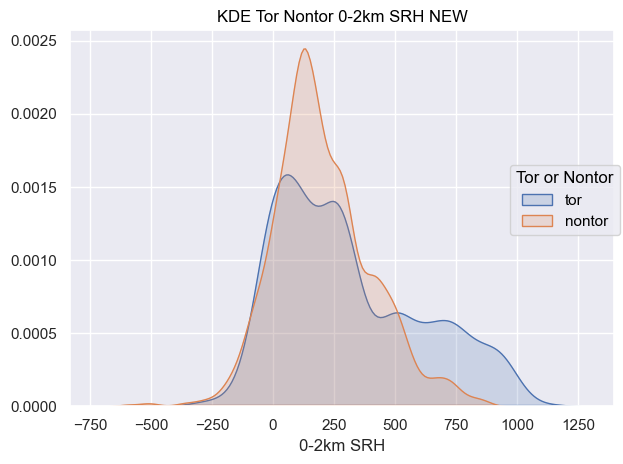

In [171]:
#plt.figure(figsize = (12, 4))
df = df_all_new
p = so.Plot(df, x='0-2km SRH', color='Tor or Nontor').add(sns.objects.Area(), 
                                                          sns.objects.KDE(common_norm=False)).label(title = 'KDE Tor Nontor 0-2km SRH NEW')
p.show()

In [316]:
x = np.nanmean(dftor[dftor['u or v'] == 'v']['195'], axis=0)
print(f'Mean TOR noncomposite v SRW: {x}')

Mean TOR noncomposite v SRW: 13.608573233160612


In [317]:
y = np.nanmean(dfnontor[dfnontor['u or v'] == 'v']['195'], axis=0)
print(f'Mean NONTOR noncomposite v SRW: {y}')

Mean NONTOR noncomposite v SRW: 10.60238636952924


In [318]:
data = dftor[dftor['u or v'] == 'v']['195']
confidence_level = 0.95
degrees_freedom = len(data) - 1
x_strd_error = stats.sem(data, nan_policy='omit')

x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)

In [320]:
data = dfnontor[dfnontor['u or v'] == 'v']['195']
confidence_level = 0.95
degrees_freedom = len(data) - 1
y_strd_error = stats.sem(data, nan_policy='omit')

y_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=y, scale=y_strd_error)

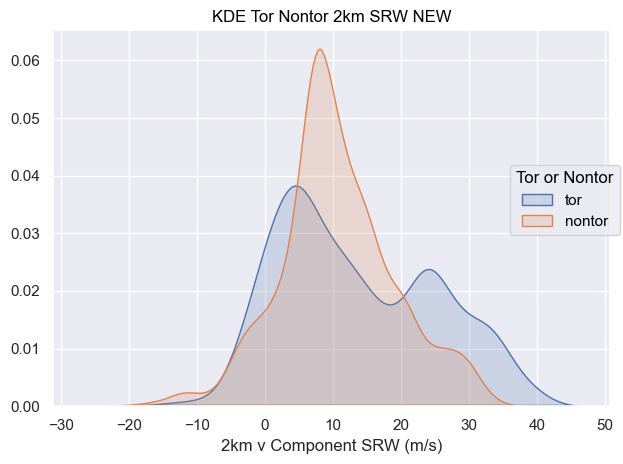

In [174]:
#plt.figure(figsize = (12, 4))
df = df_all_new
df = df[df['u or v'] == 'v']
p = so.Plot(df, x='195', color='Tor or Nontor').add(sns.objects.Area(), 
                                                    sns.objects.KDE(common_norm=False)).label(x = '2km v Component SRW (m/s)', 
                                                                                              title = 'KDE Tor Nontor 2km SRW NEW')
p.show()

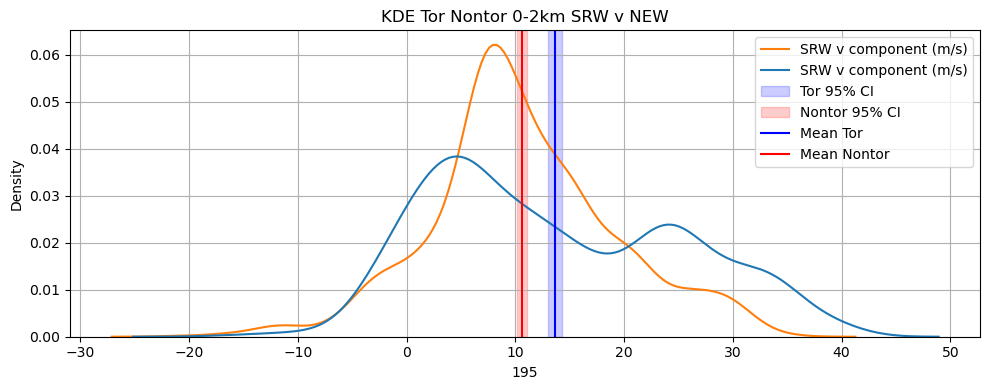

In [321]:
#plt.figure(figsize = (12, 4))
df = df_all_new
df = df[df['u or v'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='195', hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE Tor Nontor 0-2km SRW v NEW')

plt.axvspan(x_95conf[0], x_95conf[1], color='blue', alpha=0.2, label='Tor 95% CI')
plt.axvspan(y_95conf[0], y_95conf[1], color='red', alpha=0.2, label='Nontor 95% CI')
plt.axvline(x, color='blue', label='Mean Tor')
plt.axvline(x=y, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [305]:
x = np.nanmean(dftor['0-2km SRH'], axis=0)
print(f'Mean TOR not composited 0-2km SRH: {x}')
y = np.nanmean(dfnontor['0-2km SRH'], axis=0)
print(f'Mean NONTOR not composited 0-2km SRH: {y}')

Mean TOR not composited 0-2km SRH: 312.599140676654
Mean NONTOR not composited 0-2km SRH: 203.52803064047322


In [310]:
data = dftor['0-2km SRH']
confidence_level = 0.95
degrees_freedom = len(data) - 1
x_strd_error = stats.sem(data, nan_policy='omit')

x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)

In [311]:
data = dfnontor['0-2km SRH']
confidence_level = 0.95
degrees_freedom = len(data) - 1
y_strd_error = stats.sem(data, nan_policy='omit')

y_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=y, scale=y_strd_error)

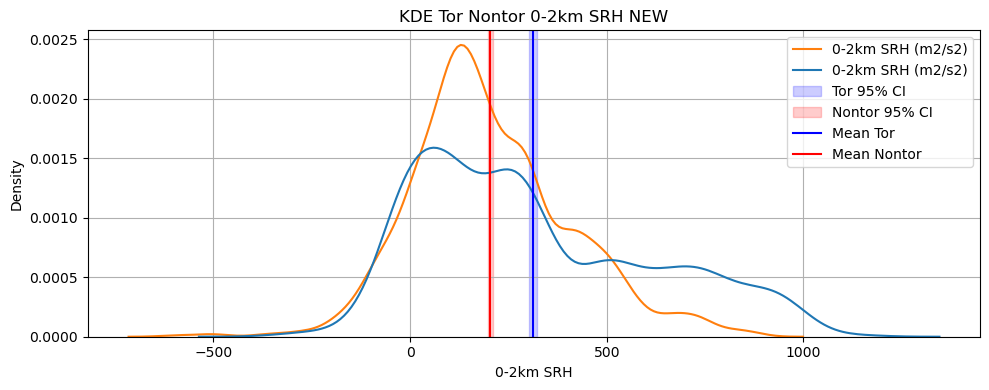

In [314]:
#plt.figure(figsize = (12, 4))
df = df_all_new
#df = df[df['u or v'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='0-2km SRH', hue='Tor or Nontor', common_norm=False, label = '0-2km SRH (m2/s2)')
                
plt.title('KDE Tor Nontor 0-2km SRH NEW')


plt.axvspan(x_95conf[0], x_95conf[1], color='blue', alpha=0.2, label='Tor 95% CI')
plt.axvspan(y_95conf[0], y_95conf[1], color='red', alpha=0.2, label='Nontor 95% CI')
plt.axvline(x, color='blue', label='Mean Tor')
plt.axvline(x=y, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [246]:
def test_stat(x, y):
    return np.nanmean(x) - np.nanmean(y)

In [247]:
from scipy.stats import permutation_test
label = '0-2km SRH'
result = permutation_test((dftor[label], dfnontor[label]), test_stat, permutation_type='independent')

In [248]:
result

PermutationTestResult(statistic=109.07111003618076, pvalue=0.0002, null_distribution=array([ 10.96155373,   2.03284125, -13.66430167, ...,   1.91468091,
         1.69263808,  11.26398763]))

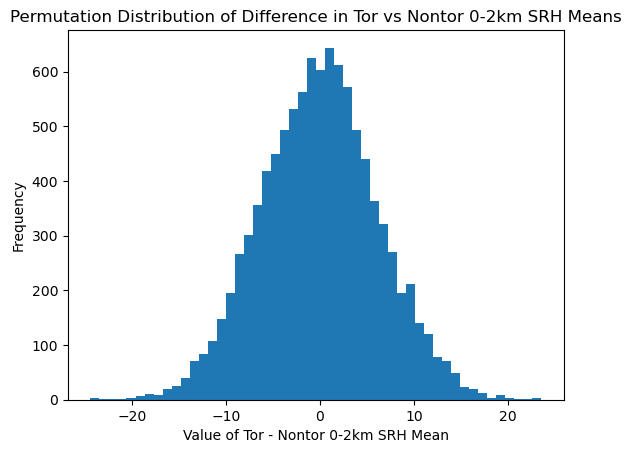

In [249]:
plt.hist(result.null_distribution, bins=50)
plt.title('Permutation Distribution of Difference in Tor vs Nontor 0-2km SRH Means')
plt.xlabel('Value of Tor - Nontor 0-2km SRH Mean')
plt.ylabel('Frequency')
plt.show()

In [250]:
# comparing if CDF of dfnontor is less than CDF of dftor

from scipy import stats
label = '0-2km SRH'
ks_statistic, p_value = stats.ks_2samp(dftor[label], dfnontor[label], alternative='less')

In [251]:
p_value

1.6657468804300307e-50

In [252]:
ks_statistic

0.1876048462255359

Note that the alternative hypotheses describe the CDFs of the underlying distributions, not the observed values of the data. For example, suppose x1 ~ F and x2 ~ G. If F(x) > G(x) for all x, the values in x1 tend to be less than those in x2.

--> Whichever one is greater than the other has smaller values in its distribution

so for ours it's saying G(x) (nontor) > F(x) (tor), meaning G(x) has smaller values

In [244]:
# comparing if CDF of dfnontor is greater than CDF of dftor

from scipy import stats
label = '0-2km SRH'
ks_statistic2, p_value2 = stats.ks_2samp(dftor[label], dfnontor[label], alternative='greater')

In [243]:
ks_statistic2

0.012246039142590866

In [242]:
p_value2

0.6069151625698262

In [230]:
from scipy.stats import permutation_test
label = '0-2km SRW Mag'
result_02_srw = permutation_test((dftor[label], dfnontor[label]), test_stat, permutation_type='independent')

In [231]:
result_02_srw

PermutationTestResult(statistic=5.574947789826577, pvalue=0.0002, null_distribution=array([ 0.12608638,  0.36883174, -0.09532573, ..., -0.09345864,
       -0.54797249, -0.04353429]))

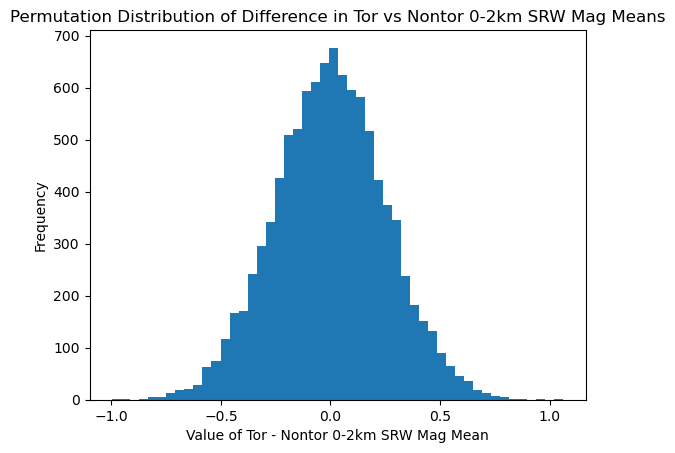

In [216]:
plt.hist(result_02_srw.null_distribution, bins=50)
plt.title('Permutation Distribution of Difference in Tor vs Nontor 0-2km SRW Mag Means')
plt.xlabel('Value of Tor - Nontor 0-2km SRW Mag Mean')
plt.ylabel('Frequency')
plt.show()

In [160]:
comp_tor_all_new_copy = comp_tor_all_new.copy()
comp_tor_all_new_copy['Tor or Nontor'] = 'tor'

comp_nontor_all_new_copy = comp_nontor_all_new.copy()
comp_nontor_all_new_copy['Tor or Nontor'] = 'nontor'

In [161]:
comp_a = pd.DataFrame()
comp_ALL = pd.concat([comp_a, comp_tor_all_new_copy, comp_nontor_all_new_copy])

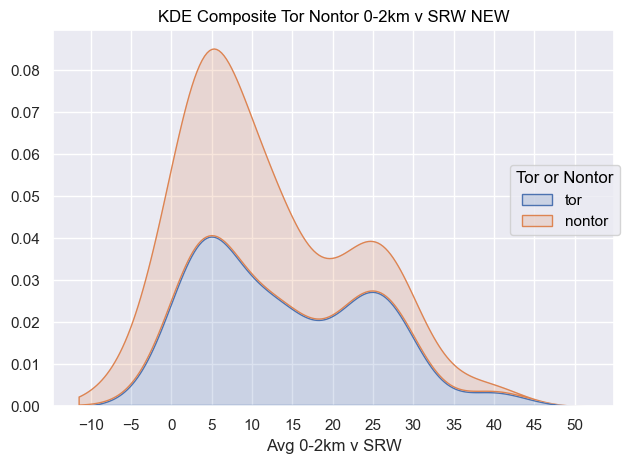

In [162]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
p = so.Plot(df, x=195, color='Tor or Nontor').add(
    sns.objects.Area(), sns.objects.KDE(common_norm=False), so.Stack()).label(
    x = 'Avg 0-2km v SRW', title = 'KDE Composite Tor Nontor 0-2km v SRW NEW').scale(x = so.Continuous().tick(every=5))
p.show()

In [178]:
x = np.nanmean(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'v'][195], axis=0)
print(f'Mean TOR composite v SRW: {x}')

Mean TOR composite v SRW: 14.057735377277472


In [179]:
y = np.nanmean(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'v'][195], axis=0)
print(f'Mean NONTOR composite v SRW: {y}')

Mean NONTOR composite v SRW: 9.972730913731565


In [271]:
data = comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'v'][195]
confidence_level = 0.95
degrees_freedom = len(data) - 1
x_strd_error = stats.sem(data)

x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)

In [275]:
data = comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'v'][195]
confidence_level = 0.95
degrees_freedom = len(data) - 1
y_strd_error = stats.sem(data)

y_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=y, scale=y_strd_error)

In [272]:
x_strd_error

0.9382717241699158

In [273]:
x_95conf

(12.200484029350944, 15.914986725204)

In [276]:
y_95conf

(2.6029050072692748, 17.342556820193856)

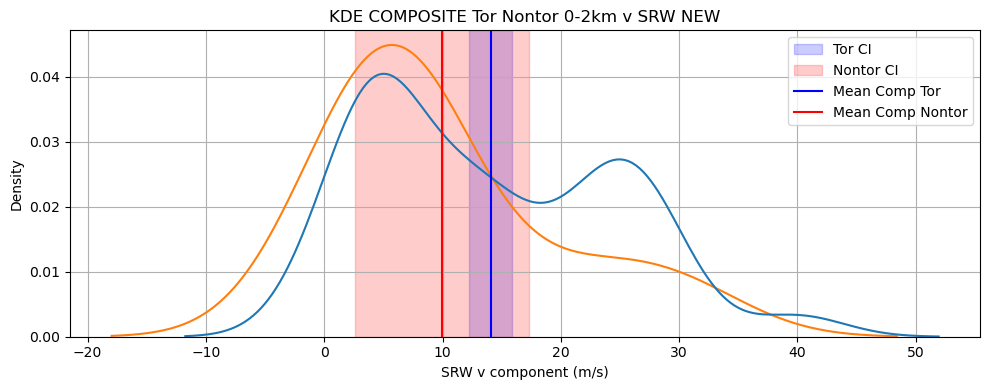

In [277]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x=195, hue='Tor or Nontor', common_norm=False)
                
plt.title('KDE COMPOSITE Tor Nontor 0-2km v SRW NEW')

plt.axvspan(x_95conf[0], x_95conf[1], color='blue', alpha=0.2, label='Tor CI')
plt.axvspan(y_95conf[0], y_95conf[1], color='red', alpha=0.2, label='Nontor CI')
plt.axvline(x, color='blue', label='Mean Comp Tor')
plt.axvline(y, color='red', label='Mean Comp Nontor')

plt.xlabel('SRW v component (m/s)')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [278]:
x = np.nanmean(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'u'][195], axis=0)
print(f'Mean TOR composite u SRW: {x}')
y = np.nanmean(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'u'][195], axis=0)
print(f'Mean NONTOR composite u SRW: {y}')

Mean TOR composite u SRW: -8.393961021227318
Mean NONTOR composite u SRW: -7.47033753061892


In [279]:
data = comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'v'][195]
confidence_level = 0.95
degrees_freedom = len(data) - 1
x_strd_error = stats.sem(data)

x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)

In [280]:
data = comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'v'][195]
confidence_level = 0.95
degrees_freedom = len(data) - 1
y_strd_error = stats.sem(data)

y_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=y, scale=y_strd_error)

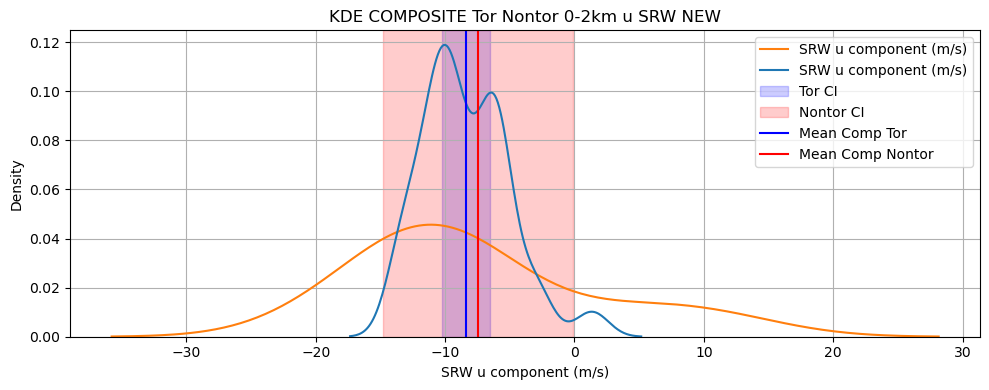

In [282]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'u']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x=195, hue='Tor or Nontor', common_norm=False, label = 'SRW u component (m/s)')
                
plt.title('KDE COMPOSITE Tor Nontor 0-2km u SRW NEW')

plt.axvspan(x_95conf[0], x_95conf[1], color='blue', alpha=0.2, label='Tor CI')
plt.axvspan(y_95conf[0], y_95conf[1], color='red', alpha=0.2, label='Nontor CI')
plt.axvline(x, color='blue', label='Mean Comp Tor')
plt.axvline(x=y, color='red', label='Mean Comp Nontor')
plt.xlabel('SRW u component (m/s)')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# SRW SRH Boxplots for NF FF and Angle Per IOP

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)]['0-2km SRH']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} 0-2km SRH per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)]['0-2km SRH']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} 0-2km SRH per VAD NEW')

    plt.show()

In [ ]:
column = 'SFC SRW Mag'
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)][f'{column}']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} SFC SRW Mag per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)][f'{column}']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} SFC SRW Mag per VAD NEW')

    plt.show()

# SRW SRH Polar Plots

In [ ]:
def srw_srh_polar_plot(field, vmax, vmin, max_radius, cbar_label):
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    
    # Tornadic points
    tor_points = ax0.scatter(df_all_new_tor['Angle'] * (np.pi/180), df_all_new_tor['Distance'], 
                             c=df_all_new_tor[field], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    
    ax0.set_title(f'All Tor {field} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    
    nontor_points = ax1.scatter(df_all_new_nontor['Angle'] * (np.pi/180), df_all_new_nontor['Distance'], 
                             c=df_all_new_nontor['0-2km SRH'], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    ax1.set_title(f'All Nontor {field} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
tor_srh_points = []
nontor_srh_points = []
for d in sorted(set(df_all_new['Date'])):
    title = f'{d} 0-2km SRH Per VAD'
    vmax = 900
    vmin = -900
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    max_radius = 60
    #vmin = 0
    #vmax = 30
    
    # Create two subplots side by side
    fig, (ax0) = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
   # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    df_all_new_date = df_all_new[(df_all_new['Date'] == d)]

    if df_all_new_date['Time From Tor (min)'].ne('nontor').any():
        
        # Tornadic points
        tor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        tor_srh_points.append(tor_points)
        
        plt.title(f'Tor {d} SRH Per VAD')

    if df_all_new_date['Time From Tor (min)'].eq('nontor').any():
    
        nontor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        nontor_srh_points.append(nontor_points)
        
        plt.title(f'Nontor {d} SRH Per VAD')
        
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax0], pad=0.1, shrink=0.8)
    cbar.set_label('0-2km SRH (m$^{2}$s$^{-2})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
   # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
srw_srh_polar_plot('0-2km SRH', 900, -900, 60, '0-2km SRH (m$^{2}$s$^{-2})$')

In [ ]:
srw_srh_polar_plot('SFC SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-500m SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-1km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-2km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

Would I have to do Barnes analysis for the wind barb distributions?

In [ ]:
def srw_srh_polar_plots_barbs(field, vmax, vmin, max_radius, cbar_label, col, skipby, title):
    import matplotlib.colors as mcolors
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
    t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    tor_points = ax0.barbs(t_u['Angle'][::skipby] * (np.pi/180), t_u['Distance'][::skipby], 
                              t_u[col][::skipby], t_v[col][::skipby], t_u[field][::skipby], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    
    ax0.set_title(f'All Tor {col} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # Compute wind speed
    nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    ntspeed = np.sqrt(nta)
    
    nontor_points = ax1.barbs(nt_u['Angle'][::skipby] * (np.pi/180), nt_u['Distance'][::skipby], 
                             nt_u[col][::skipby], nt_v[col][::skipby], ntspeed[::skipby], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(f'{field} ' + cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle(f'{field} ' + title)
    plt.show()

In [ ]:
srw_srh_polar_plots_barbs('SFC SRW Mag', 30, 0, 60, '(ms$^{-1})$', '0', 10, 'Every 10 VADs')

In [ ]:
srw_srh_polar_plots_barbs('0-2km SRH', 30, 0, 60, '(ms$^{-1})$', '0', 10, 'and SFC SRW Every 10 VADs')

In [ ]:
srw_srh_polar_plots_barbs('0-2km SRH', 30, 0, 60, '(ms$^{-1})$', '194', 10, 'and 0-2km SRW Every 10 VADs')

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df0 = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']#[df_all_new['Date'] == '20230527']
df = df0[df0['Date'] == '20230615']
df_all_new_tor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) < 0)]
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

# Compute wind speed
ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
# tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
#                           t_u[col][::10], t_v[col][::10], t_u['0-2km SRH'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

tor_points = ax0.barbs(t_u['Angle'] * (np.pi/180), t_u['Distance'], 
                          t_u[col], t_v[col], t_u['0-2km SRH'], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All PreTor Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) == 0)]
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

# Compute wind speed
nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
ntspeed = np.sqrt(nta)

# nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
#                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

nontor_points = ax1.barbs(nt_u['Angle'] * (np.pi/180), nt_u['Distance'], 
                         nt_u[col], nt_v[col], ntspeed, cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All During Tor Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('SRH (m$^{2}$s$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('SFC SRW Pretor vs During Tor 20220523')
plt.show()

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

t_u_02km = np.nansum([t_u['195'], - t_u['0']], axis=0)
t_v_02km = np.nansum([t_v['195'], - t_v['0']], axis=0)
# Compute wind speed
ta = np.nansum([t_u_02km**2, t_v_02km**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
                          t_u_02km[::10], t_v_02km[::10], tspeed[::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All Tor {col} Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

nt_u_02km = np.nansum([nt_u['195'], - nt_u['0']], axis=0)
nt_v_02km = np.nansum([nt_v['195'], - nt_v['0']], axis=0)
# Compute wind speed
nta = np.nansum([nt_u_02km**2, nt_v_02km**2], axis=0)
ntspeed = np.sqrt(nta)

nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
                         nt_u_02km[::10], nt_v_02km[::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All Nontor 0-2km Vertical Shear Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('Shear (ms$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('0-2km Vertical Wind Shear Every 10 points', style='oblique')
plt.show()

# Shear mag boxplots

In [ ]:
def tor_boxplot(data_dict, title):
    
    labels = ['NonTor', 'TorAll', 'PreTor', 'DuringTor', 'PostTor']

    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([data_dict['nf_nontor'], data_dict['nf_tor'], data_dict['nf_pretor'], data_dict['nf_dtor'], 
                 data_dict['nf_posttor']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title} Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([data_dict['ff_nontor'], data_dict['ff_tor'], data_dict['ff_pretor'], data_dict['ff_dtor'], 
                 data_dict['ff_posttor']], labels = labels)
    
    ax1.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title} Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot(mag_all_500m, '0-500m Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_500m_new, '0-500m Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_1km, '0-1km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_1km_new, '0-1km Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_2km, '0-2km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_2km_new, '0-2km Shear Magnitude NEW')

# Case Metadata

Per Case

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Date'] == d]['Distance'])
    counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Date'] == d]['Angle'])
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
    ax0.set_xlabel('Distance From Meso (km)')
    ax0.set_ylabel('VADs Count')
    ax0.set_title(f'Tornadic Case VADs Count per Distance {d} NEW')
    ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
    ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
    ax1.set_title(f'Case VADs Count per Angle {d} NEW')
    fig.suptitle(f'{d} VADs Distance and Angle Relative to Meso NEW')
    plt.show()

All Cases

In [ ]:
counts_dist, bins_dist = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle')
plt.show()

In [ ]:
counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance (New 2ndTrip)')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle (New 2ndTrip)')
plt.show()

# Temporal SRH and SRW?

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] == 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW During Tor')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] > 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW Pre Tor')
        p.show()

In [ ]:
df_all_new

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = 'SFC SRW Mag'
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=4, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['SFC SRW Mag'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('SFC SRW Mag')
        
            ax1.plot(df['Datetime'], df['0-500m SRW Mag'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-500m SRW Mag')
        
            ax2.plot(df['Datetime'], df['0-1km SRW Mag'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-1km SRW Mag')
        
            ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRW')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} {col} Tor')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['0-500m SRH'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('0-500m SRH')
        
            ax1.plot(df['Datetime'], df['0-1km SRH'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-1km SRH')
        
            ax2.plot(df['Datetime'], df['0-2km SRH'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-2km SRH')
        
            # ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            # ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRH')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            # ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            # ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} SRH Over Time')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = '0-500m SRW Mag'
n = 10
for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
        plot = plt.plot(df['Datetime'], df[col])
        plt.xticks(df['Datetime'][::20], rotation=45, ha='right')
        #plt.setp(plot.axes.get_xticklabels(), visible=False)
        #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            plt.ylabel(col)
            plt.xlabel('Time (UTC)')
            plt.title(f'{d} {col} Tor')
            
            plt.show()
            
        else:
            plt.show()

# Mesocyclone strength

In [ ]:
def meso_stats_get(meso_stats, features_shear_xr, d, meso_id, df_all_new):
    meso_max = []
    dates = []
    if not isinstance(meso_id, (list, set)):
        meso_id = [meso_id]
        
        meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)
    
    meso_ids = meso_indeces.index
    
    if not isinstance(meso_ids, (list, set)):
        meso_ids = [meso_ids]
        
        meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)
    
    meso_ids_stats = meso_indeces2.index

    nearest_vad_time_idx = []
    
    df_all_new_date = df_all_new[df_all_new['Date'] == d]

    #df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    
    for i in df_all_new_date['Datetime']:
        timet = meso_stats['time'].to_pandas()    
        time = pd.to_datetime(timet)
        dt_df = pd.Series(i)
        dta = pd.to_datetime(dt_df)
        dt = np.array(dta)
        nearest_vad_time = find_nearest(time, dt)
        nearest_vad_time_idx.append(nearest_vad_time)

    # timet = meso_stats['time'].to_pandas()
    # for i in timet:
    #     #timet = meso_stats['time'].to_pandas()
    #     # for t in timet:
    #     #     t0 = datetime.strptime(t, '%Y-%m-%d %H:%M:%S')
    #     #     t1 = np.array(t0)
    #     #     t2 = t1.astype('datetime64[ns]')
            
    #     #time = pd.to_datetime(i)
    #     #dt = datetime.fromtimestamp(dt_ts)
    #     #dt = to_dt[i]
    #     #dt_strp = datetime.strptime(i, '%Y-%m-%d %H:%M:%S')
    #     #dt_array = np.array(dt_strp)
    #     #dt = dt_array.astype('datetime64[ns]')
    #     time_df = pd.Series(i)
    #     timea = pd.to_datetime(time_df)
    #     time = np.array(timea)
    #     #dta = pd.to_datetime(dt_df)
    #     #dt = np.array(dta)
    #     df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    #     #print(f'i dtype: {dt.dtype}')
    #     #print((df_datetime).dtype)
    #     #print(f'time dtype: {(time).dtype}')
        
    #     #print(f'time shape:{np.shape(time)}')
    #     #print(f'i shape:{np.shape(dt)}')
    #     nearest_vad_time = find_nearest(df_datetime, time)
        #nearest_vad_time_idx.append(nearest_vad_time)
    
    wanted_meso_max = meso_stats['max'][meso_ids_stats].values
    meso_max.append(wanted_meso_max)
    wanted_meso_max_nearest = meso_stats['max'][nearest_vad_time_idx].values
    dates.append(d)

    time = meso_stats['time'][nearest_vad_time_idx]

    fig = plt.figure()
    plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
    plt.title(f'Maximum Azimuthal Shear Over Time Of Target Mesocyclones {d}')
    plt.xlabel('Time')
    plt.ylabel('Azshear')
    plt.show()

    return wanted_meso_max_nearest, dates, time

In [ ]:
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240528', '20240602']

In [ ]:
meso_ids_dict = {
    
    '20220523': [8, 24, 44, 10, 26],
    '20220524': [1, 11],
    '20220611': [9, 18, 59, 119, 186, 236, 289, 427],
    '20230524': [8, 27],
    '20230527': [8,16, 36, 57],
    '20230601': [3, 5],
    '20230609': [1, 13, 15],
    '20230611': [13, 27, 43,55, 80, 82, 84, 145, 162],
    '20230612': [21, 32, 81, 106, 136],
    '20230613': [1],
    '20230615': [201, 481, 749, 1178],
    '20240427': [15, 191, 506],
    '20240502': [1, 23, 38, 58],
    '20240504': [15, 192, 224, 311],
    '20240519': [3, 9, 12, 27, 29, 43],
    '20240523': [1, 10, 17, 20],
    '20240528': [49, 194, 237, 308],
    '20240602': [1, 5, 8]
}
    


In [ ]:
meso_azshear_df = pd.DataFrame()

for key in meso_ids_dict:
    d = key
    print(d)
    meso_id = np.array(meso_ids_dict[d])
    print(meso_id)
    meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')
    tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
    # tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
    # latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)
    # meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
    #                                                                            np.array(latitude_weighted_tobac_meso),
    #                                                                            np.array(longitude_weighted_tobac_meso),
    #                                                                            meso_times[:-1])
    meso_max, dates, time = meso_stats_get(meso_stats, tobac_features_xr_shear, d, meso_id, df_all_new)

    df = pd.DataFrame()
    df['Time'] = time
    print(np.shape(time))
    df['Meso_Max'] = pd.Series(np.array(meso_max).flatten())
    print(np.shape(df['Meso_Max']))
    df['Date'] = dates * np.size(df['Meso_Max'])

    meso_azshear_df = pd.concat([meso_azshear_df, df])

In [ ]:
meso_azshear_df

In [ ]:
df_all_new

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30
for d in sorted(set(meso_azshear_df['Date'])):
    
    col = '0'
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

    df_all_new_d = df_all_new[df_all_new['Date'] == d]
    #df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    u = df_all_new_d[df_all_new_d['u or v'] == 'u']
    v = df_all_new_d[df_all_new_d['u or v'] == 'v']

    print(f'u shape: {np.shape(u)}')

    meso_d = meso_azshear_df[meso_azshear_df['Date'] == d]
    meso_max = meso_d['Meso_Max']
    
    print(f' meso shape: {np.shape(meso_max)}')
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    points = ax0.barbs(u['Angle'][::10] * (np.pi/180), u['Distance'][::10], 
                              u[col][::10], v[col][::10], meso_d['Meso_Max'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

    if df_all_new_d['Time From Tor (min)'].ne('nontor').any():
        ax0.set_title(f'All Tor {d} Per VAD')

    else:
        ax0.set_title(f'All NonTor {d} Per VAD')
    
    # ax1.set_rlabel_position(-22.5)
    # ax1.grid(True, linestyle=':')
    # # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    # ax1.set_theta_zero_location('E')
    # ax1.set_theta_direction(-1)
    # ax1.set_ylim([0, max_radius])
    # # Shade regions
    # nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    # ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    # df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    # nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    # nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # # Compute wind speed
    # nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    # ntspeed = np.sqrt(nta)
    
    # nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
    #                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    # ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    # ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label('Meso AzShear (s$^{-1})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle('SFC SRW Every 10 points')
    plt.show()